In [1]:
from helpers import *
import numpy as np
from pandas import DataFrame, concat
import pandas as pd
from IPython.display import display, Markdown

In [2]:
origin = pd.read_csv(
    "지역화폐_월별_업종대분류.csv",
    encoding="utf-8-sig"
)


In [3]:
origin.head()

,기준년월,행정동코드,매출금액,활성화비율,행정구역,총인구수,월유동인구수,년도,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타
0,202307,4111156000,41128684.0,100.0,경기도 수원시 장안구 파장동,22480.0,241011.94,2023,274,3,248,1,6,4,14,21,25,97,19
1,202308,4111156000,5115679.0,100.0,경기도 수원시 장안구 파장동,22451.0,241268.02,2023,274,3,248,1,6,4,14,21,25,97,19
2,202309,4111156000,436318.0,100.0,경기도 수원시 장안구 파장동,22410.0,236580.40,2023,274,3,248,1,6,4,14,21,25,97,19
3,202310,4111156000,631469.0,100.0,경기도 수원시 장안구 파장동,23628.0,268762.16,2023,274,3,248,1,6,4,14,21,25,97,19
4,202311,4111156000,591386.0,100.0,경기도 수원시 장안구 파장동,24542.0,253510.66,2023,274,3,248,1,6,4,14,21,25,97,19


In [4]:
df1 = my_qtcheck.set_type(origin, as_category=["년도", "기준년월"])

<class 'pandas.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   기준년월          6240 non-null   category
 1   행정동코드         6240 non-null   int64   
 2   매출금액          6240 non-null   float64 
 3   활성화비율         6240 non-null   float64 
 4   행정구역          6240 non-null   str     
 5   총인구수          6240 non-null   float64 
 6   월유동인구수        6240 non-null   float64 
 7   년도            6240 non-null   category
 8   가맹점수_소매       6240 non-null   int64   
 9   가맹점수_숙박       6240 non-null   int64   
 10  가맹점수_음식       6240 non-null   int64   
 11  가맹점수_부동산      6240 non-null   int64   
 12  가맹점수_과학·기술    6240 non-null   int64   
 13  가맹점수_시설관리·임대  6240 non-null   int64   
 14  가맹점수_교육       6240 non-null   int64   
 15  가맹점수_보건의료     6240 non-null   int64   
 16  가맹점수_예술·스포츠   6240 non-null   int64   
 17  가맹점수_수리·개인    6240 non-null   int64   
 18  가맹점수_기타       6240 

In [5]:
# 중복값 제거
df2 = my_qtcheck.check_duplicates(df1)
df2.head()

중복된 행의 수: 0


,기준년월,행정동코드,매출금액,활성화비율,행정구역,총인구수,월유동인구수,년도,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타
0,202307,4111156000,41128684.0,100.0,경기도 수원시 장안구 파장동,22480.0,241011.94,2023,274,3,248,1,6,4,14,21,25,97,19
1,202308,4111156000,5115679.0,100.0,경기도 수원시 장안구 파장동,22451.0,241268.02,2023,274,3,248,1,6,4,14,21,25,97,19
2,202309,4111156000,436318.0,100.0,경기도 수원시 장안구 파장동,22410.0,236580.40,2023,274,3,248,1,6,4,14,21,25,97,19
3,202310,4111156000,631469.0,100.0,경기도 수원시 장안구 파장동,23628.0,268762.16,2023,274,3,248,1,6,4,14,21,25,97,19
4,202311,4111156000,591386.0,100.0,경기도 수원시 장안구 파장동,24542.0,253510.66,2023,274,3,248,1,6,4,14,21,25,97,19


In [6]:
df2 = df2.drop(columns=["활성화비율"])

In [7]:
# 결측치 비율 확인
my_qtcheck.check_missing_values(df2)

,Missing Count,Missing Ratio (%)
기준년월,0,0.0
행정동코드,0,0.0
매출금액,0,0.0
행정구역,0,0.0
총인구수,0,0.0
월유동인구수,0,0.0
년도,0,0.0
가맹점수_소매,0,0.0
가맹점수_숙박,0,0.0
가맹점수_음식,0,0.0


In [8]:
df2_categorical_qtcheck = my_qtcheck.categorical_summary(df2, save_path=None)
df2_numerical_qtcheck = my_qtcheck.numerical_summary(df2, save_path=None)

📊 컬럼 '기준년월'의 value_counts():


,count
기준년월,
202307,260
202308,260
202309,260
202310,260
202311,260
202312,260
202401,260
202402,260
202403,260


📊 컬럼 '년도'의 value_counts():


,count
년도,
2023,1560
2024,3120
2025,1560


In [9]:
display(df2)
display(df2_categorical_qtcheck)
display(df2_numerical_qtcheck.T)

,기준년월,행정동코드,매출금액,행정구역,총인구수,월유동인구수,년도,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타
0,202307,4111156000,41128684.0,경기도 수원시 장안구 파장동,22480.0,241011.94,2023,274,3,248,1,6,4,14,21,25,97,19
1,202308,4111156000,5115679.0,경기도 수원시 장안구 파장동,22451.0,241268.02,2023,274,3,248,1,6,4,14,21,25,97,19
2,202309,4111156000,436318.0,경기도 수원시 장안구 파장동,22410.0,236580.40,2023,274,3,248,1,6,4,14,21,25,97,19
3,202310,4111156000,631469.0,경기도 수원시 장안구 파장동,23628.0,268762.16,2023,274,3,248,1,6,4,14,21,25,97,19
4,202311,4111156000,591386.0,경기도 수원시 장안구 파장동,24542.0,253510.66,2023,274,3,248,1,6,4,14,21,25,97,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6235,202502,4167053000,63164.0,경기도 여주시 오학동,18208.0,57216.81,2025,193,2,268,0,6,1,36,12,31,84,20
6236,202503,4167053000,119778.0,경기도 여주시 오학동,18222.0,74042.89,2025,193,2,268,0,6,1,36,12,31,84,20
6237,202504,4167053000,79864.0,경기도 여주시 오학동,18229.0,61845.05,2025,193,2,268,0,6,1,36,12,31,84,20
6238,202505,4167053000,462451.0,경기도 여주시 오학동,18213.0,70867.16,2025,193,2,268,0,6,1,36,12,31,84,20


,기준년월,년도
count,6240,6240
unique,24,3
top,202307,2024
freq,260,3120


,행정동코드,매출금액,총인구수,월유동인구수,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타
count,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0
mean,4131567895.384615,18829866.649038,26059.542468,468258.3433,209.217308,2.947115,255.900962,0.760577,9.325,2.758654,76.174038,24.150962,33.043269,98.939423,21.418269
std,15590848.095135,74064028.843516,12320.289688,557773.449512,135.586095,6.011377,180.953453,1.081122,9.267938,3.012783,68.417115,20.087849,24.4065,63.056567,15.802345
min,4111156000.0,386.0,978.0,511.86,6.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,4117358750.0,322422.75,17583.5,102517.29,121.0,0.0,133.75,0.0,3.0,1.0,28.0,9.0,15.0,55.0,11.0
50%,4128157000.0,846558.0,24476.0,286276.045,182.5,1.0,214.0,0.0,7.0,2.0,55.0,20.0,28.5,87.0,18.0
75%,4145334250.0,2145762.5,34141.5,593990.425,260.0,3.0,327.25,1.0,12.0,4.0,103.0,33.0,45.0,126.0,27.0
max,4167053000.0,892136990.0,69751.0,3405776.5,1176.0,57.0,1240.0,6.0,84.0,26.0,470.0,111.0,142.0,359.0,96.0
rel_diff,0.000826,21.242855,0.064698,0.635688,0.146396,1.947115,0.195799,inf,0.332143,0.379327,0.384983,0.207548,0.159413,0.137235,0.189904
rdiff_flag,similar,large_diff,similar,large_diff,diff,large_diff,diff,large_diff,diff,diff,diff,diff,diff,diff,diff


In [10]:
df2.to_excel("local_qtcheck.xlsx", index=False)
df2_categorical_qtcheck.to_excel("local_categorical_qtcheck.xlsx")
df2_numerical_qtcheck.to_excel("local_numerical_qtcheck.xlsx")

In [11]:
# 4. 변수 유형 분류
# 종속변수
target = "매출금액"
# 종속변수 연속형 여부
target_is_continuous = True

# 명목형 변수
nominal_cols = my_qtcheck.get_categorical_column_names(df2)
# 연속형 변수
continuous_cols = my_qtcheck.get_number_column_names(df2)

if target_is_continuous:
    # 연속형 변수 이름에서 종속변수 항목 제거
    continuous_cols.remove(target)
else:
    # 명목형 변수 이름에서 종속변수 항목 제거
    nominal_cols.remove(target)

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("명목형 :", nominal_cols)
print("연속형 :", continuous_cols)

종속변수 : 매출금액
종속변수 유형: 연속형
명목형 : ['기준년월', '년도']
연속형 : ['행정동코드', '총인구수', '월유동인구수', '가맹점수_소매', '가맹점수_숙박', '가맹점수_음식', '가맹점수_부동산', '가맹점수_과학·기술', '가맹점수_시설관리·임대', '가맹점수_교육', '가맹점수_보건의료', '가맹점수_예술·스포츠', '가맹점수_수리·개인', '가맹점수_기타']


In [12]:
# 품질 점검 완료 데이터 셋 가져오기
origin = pd.read_excel("local_qtcheck.xlsx")
num_desc = pd.read_excel("local_numerical_qtcheck.xlsx", index_col=0)
cat_desc = pd.read_excel("local_categorical_qtcheck.xlsx", index_col=0)

In [13]:
# 타입 변환(명목형 확정)
df3 = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   기준년월          6240 non-null   category
 1   행정동코드         6240 non-null   int64   
 2   매출금액          6240 non-null   int64   
 3   행정구역          6240 non-null   str     
 4   총인구수          6240 non-null   int64   
 5   월유동인구수        6240 non-null   float64 
 6   년도            6240 non-null   category
 7   가맹점수_소매       6240 non-null   int64   
 8   가맹점수_숙박       6240 non-null   int64   
 9   가맹점수_음식       6240 non-null   int64   
 10  가맹점수_부동산      6240 non-null   int64   
 11  가맹점수_과학·기술    6240 non-null   int64   
 12  가맹점수_시설관리·임대  6240 non-null   int64   
 13  가맹점수_교육       6240 non-null   int64   
 14  가맹점수_보건의료     6240 non-null   int64   
 15  가맹점수_예술·스포츠   6240 non-null   int64   
 16  가맹점수_수리·개인    6240 non-null   int64   
 17  가맹점수_기타       6240 non-null   int64   
dtypes: category(2), flo

In [14]:
column_means = {
    "매출금액": "지역화폐 매출",
    "행정동코드": "행정동코드",
    "총인구수": "총인구수",
    "월유동인구수": "월유동인구수",
    "가맹점수_소매": "가맹점수_소매",
    "가맹점수_숙박": "가맹점수_숙박",
    "가맹점수_음식": "가맹점수_음식",
    "가맹점수_부동산": "가맹점수_부동산",
    "가맹점수_과학·기술": "가맹점수_과학·기술",
    "가맹점수_시설관리·임대": "가맹점수_시설관리·임대",
    "가맹점수_교육": "가맹점수_교육",
    "가맹점수_보건의료": "가맹점수_보건의료",
    "가맹점수_예술·스포츠": "가맹점수_예술·스포츠",
    "가맹점수_수리·개인": "가맹점수_수리·개인",
    "가맹점수_기타": "가맹점수_기타",
    "기준년월": "기준년월",
    "년도": "년도"
}

In [15]:
# 종속변수 기술통계량 추출
num_desc.loc[[target]].T

,매출금액
count,6240
mean,18829866.649038
std,74064028.843516
min,386.0
25%,322422.75
50%,846558.0
75%,2145762.5
max,892136990.0
rel_diff,21.242855
rdiff_flag,large_diff


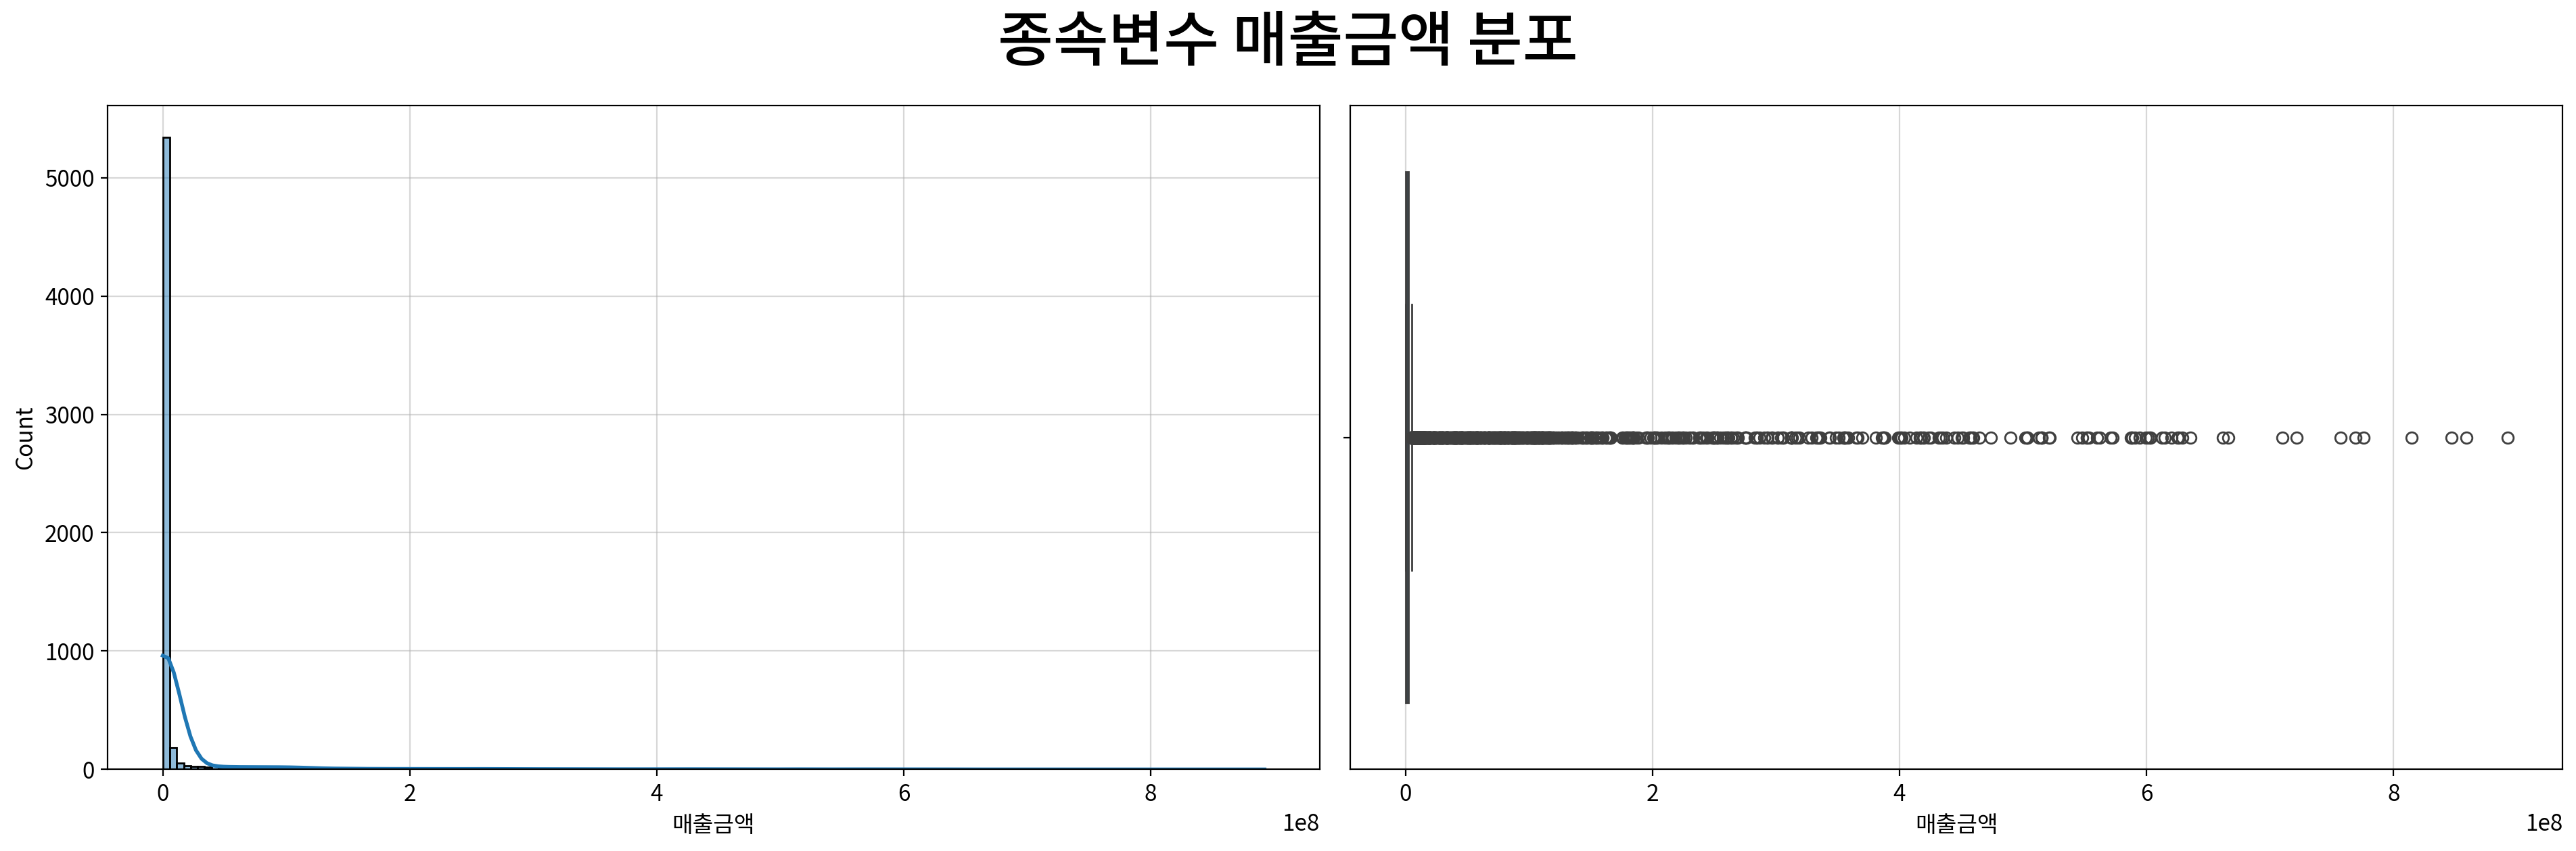

,매출금액
count,6240
mean,18829866.649038
std,74064028.843516
min,386.0
25%,322422.75
50%,846558.0
75%,2145762.5
max,892136990.0
rel_diff,21.242855
rdiff_flag,large_diff


In [16]:
# 02. 단변량 분석
# 1. 연속형 종속변수에 대한 단변량 분석
# 1행 2열 서브플롯 구성
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 x 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2,
                       title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df3, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df3, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
num_desc[num_desc.index == target].T

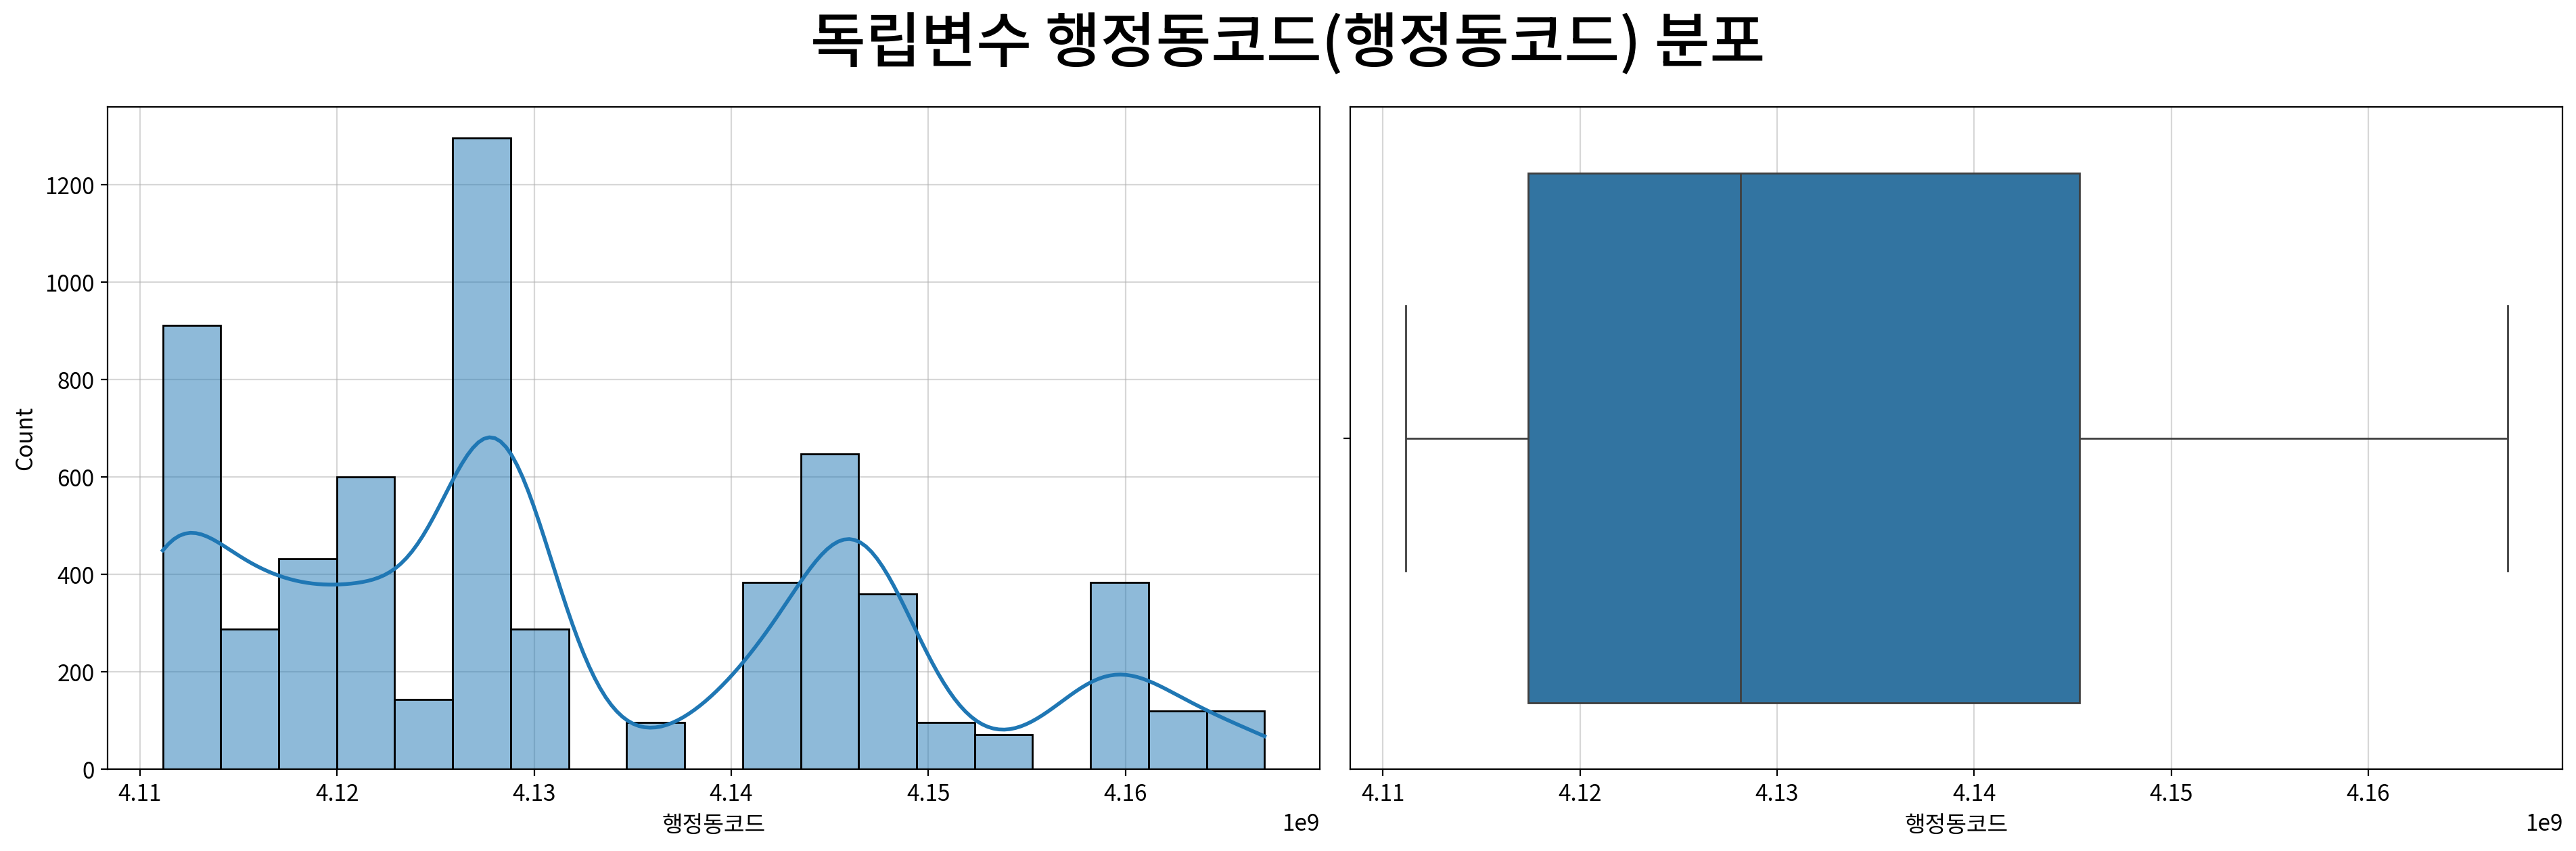

,행정동코드
count,6240
mean,4131567895.384615
std,15590848.095135
min,4111156000.0
25%,4117358750.0
50%,4128157000.0
75%,4145334250.0
max,4167053000.0
rel_diff,0.000826
rdiff_flag,similar


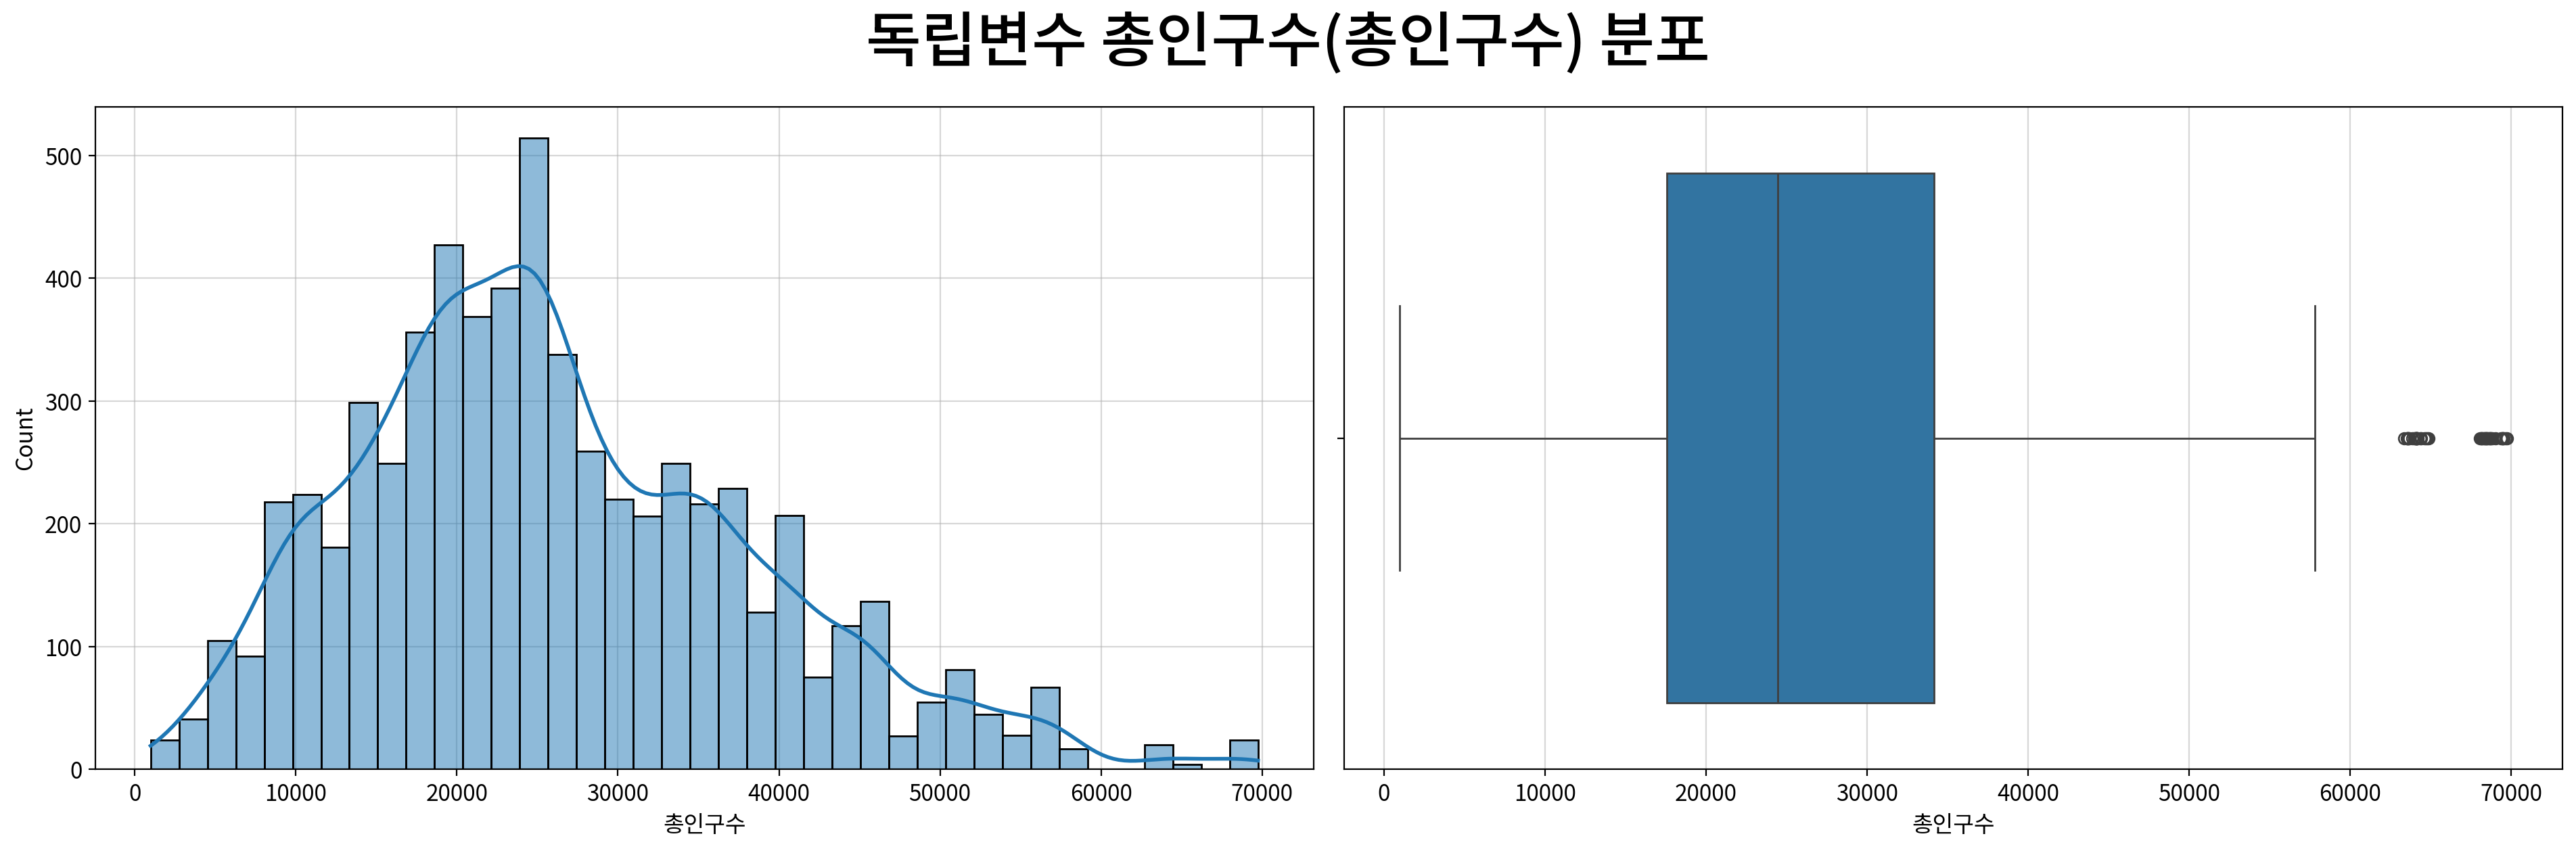

,총인구수
count,6240
mean,26059.542468
std,12320.289688
min,978.0
25%,17583.5
50%,24476.0
75%,34141.5
max,69751.0
rel_diff,0.064698
rdiff_flag,similar


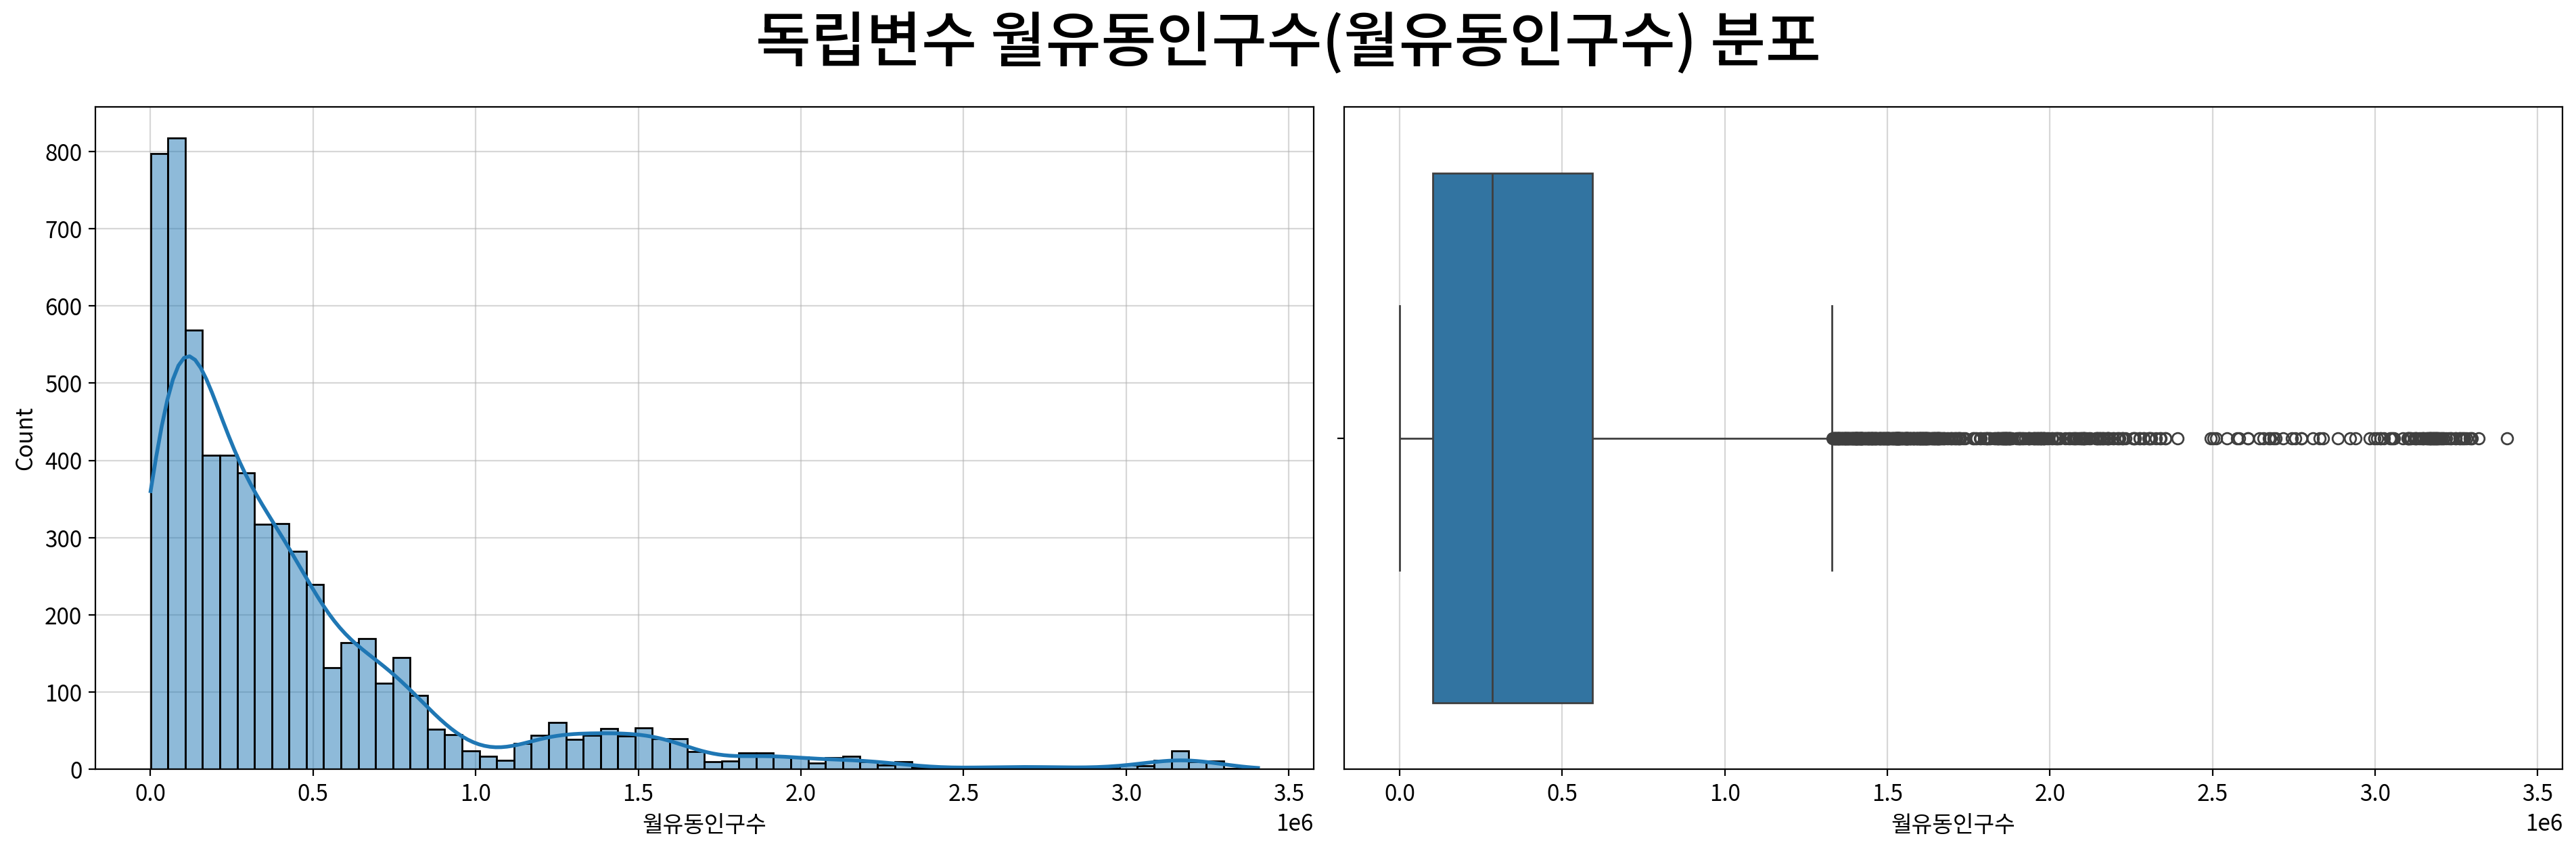

,월유동인구수
count,6240
mean,468258.3433
std,557773.449512
min,511.86
25%,102517.29
50%,286276.045
75%,593990.425
max,3405776.5
rel_diff,0.635688
rdiff_flag,large_diff


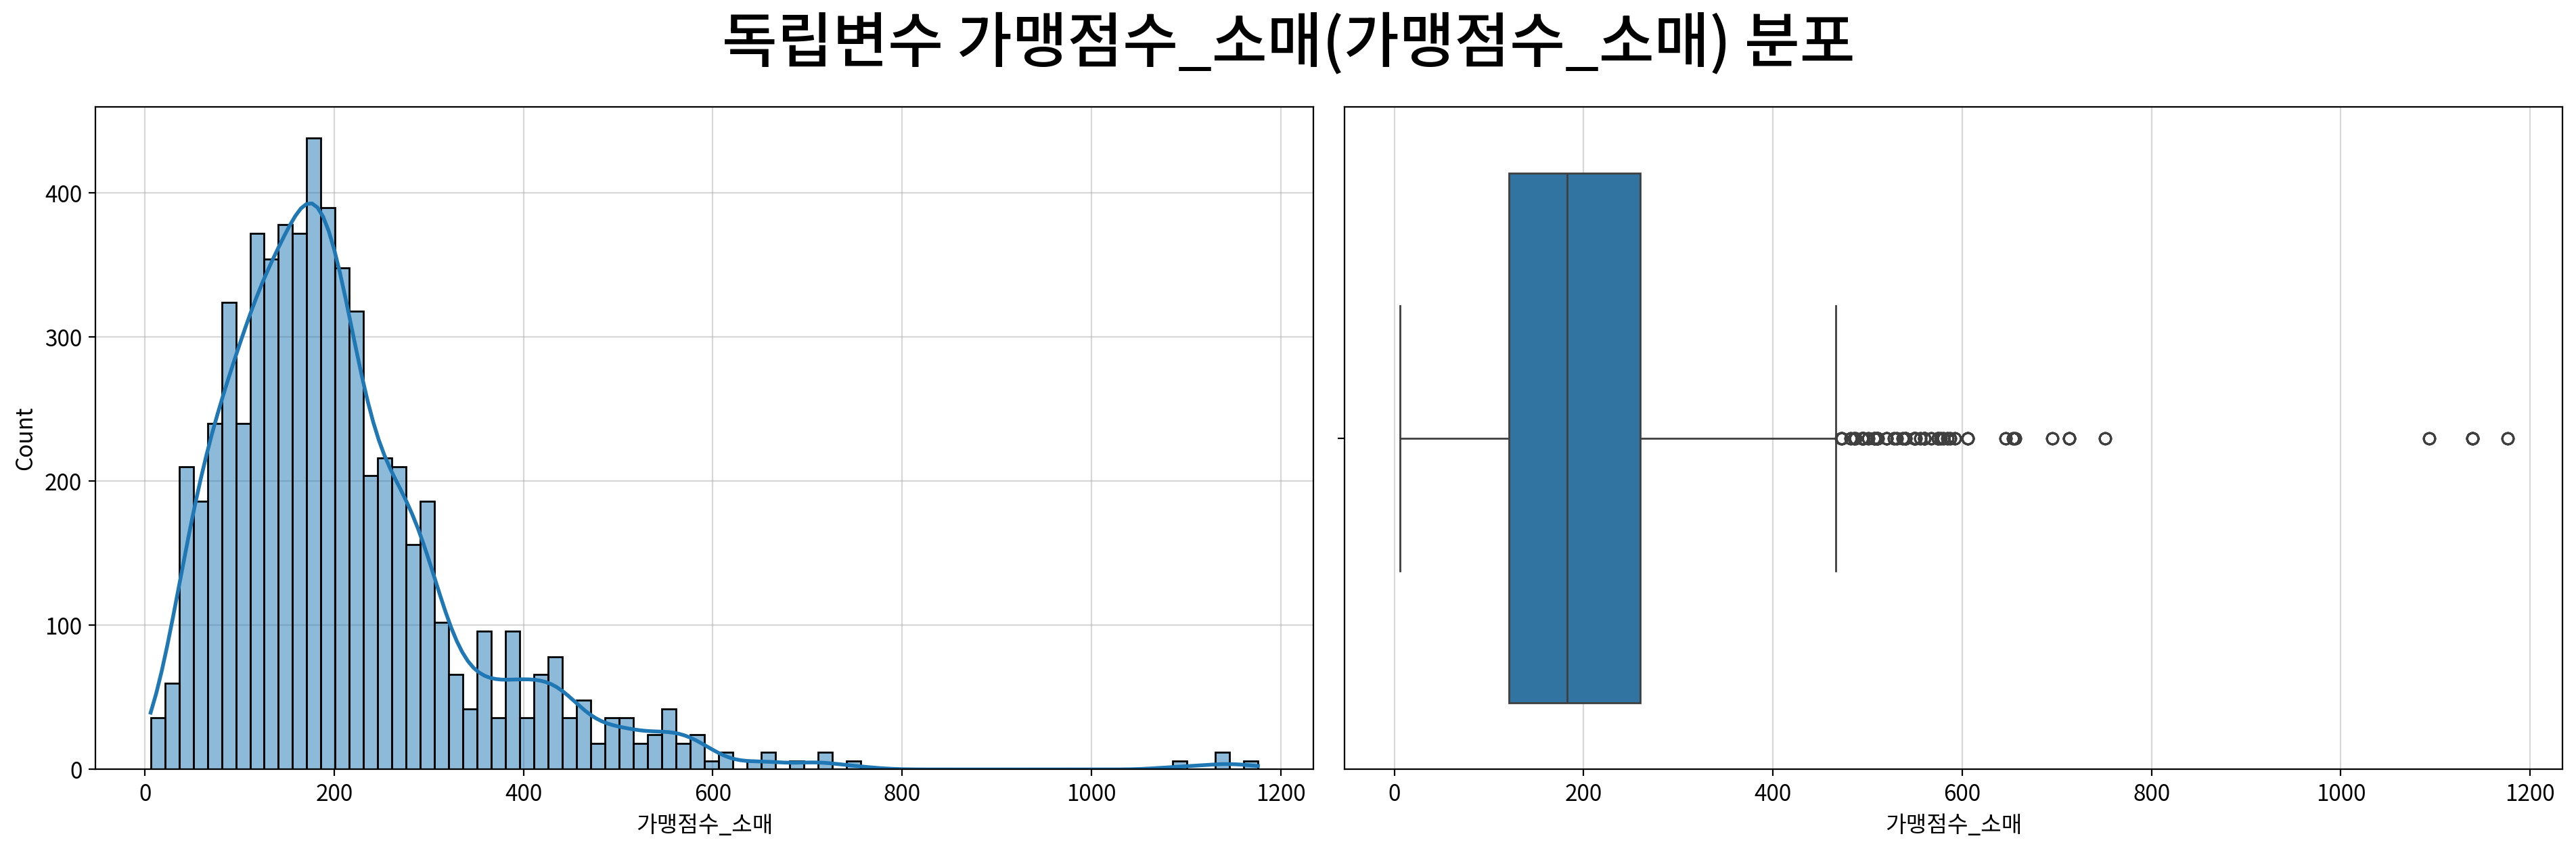

,가맹점수_소매
count,6240
mean,209.217308
std,135.586095
min,6.0
25%,121.0
50%,182.5
75%,260.0
max,1176.0
rel_diff,0.146396
rdiff_flag,diff


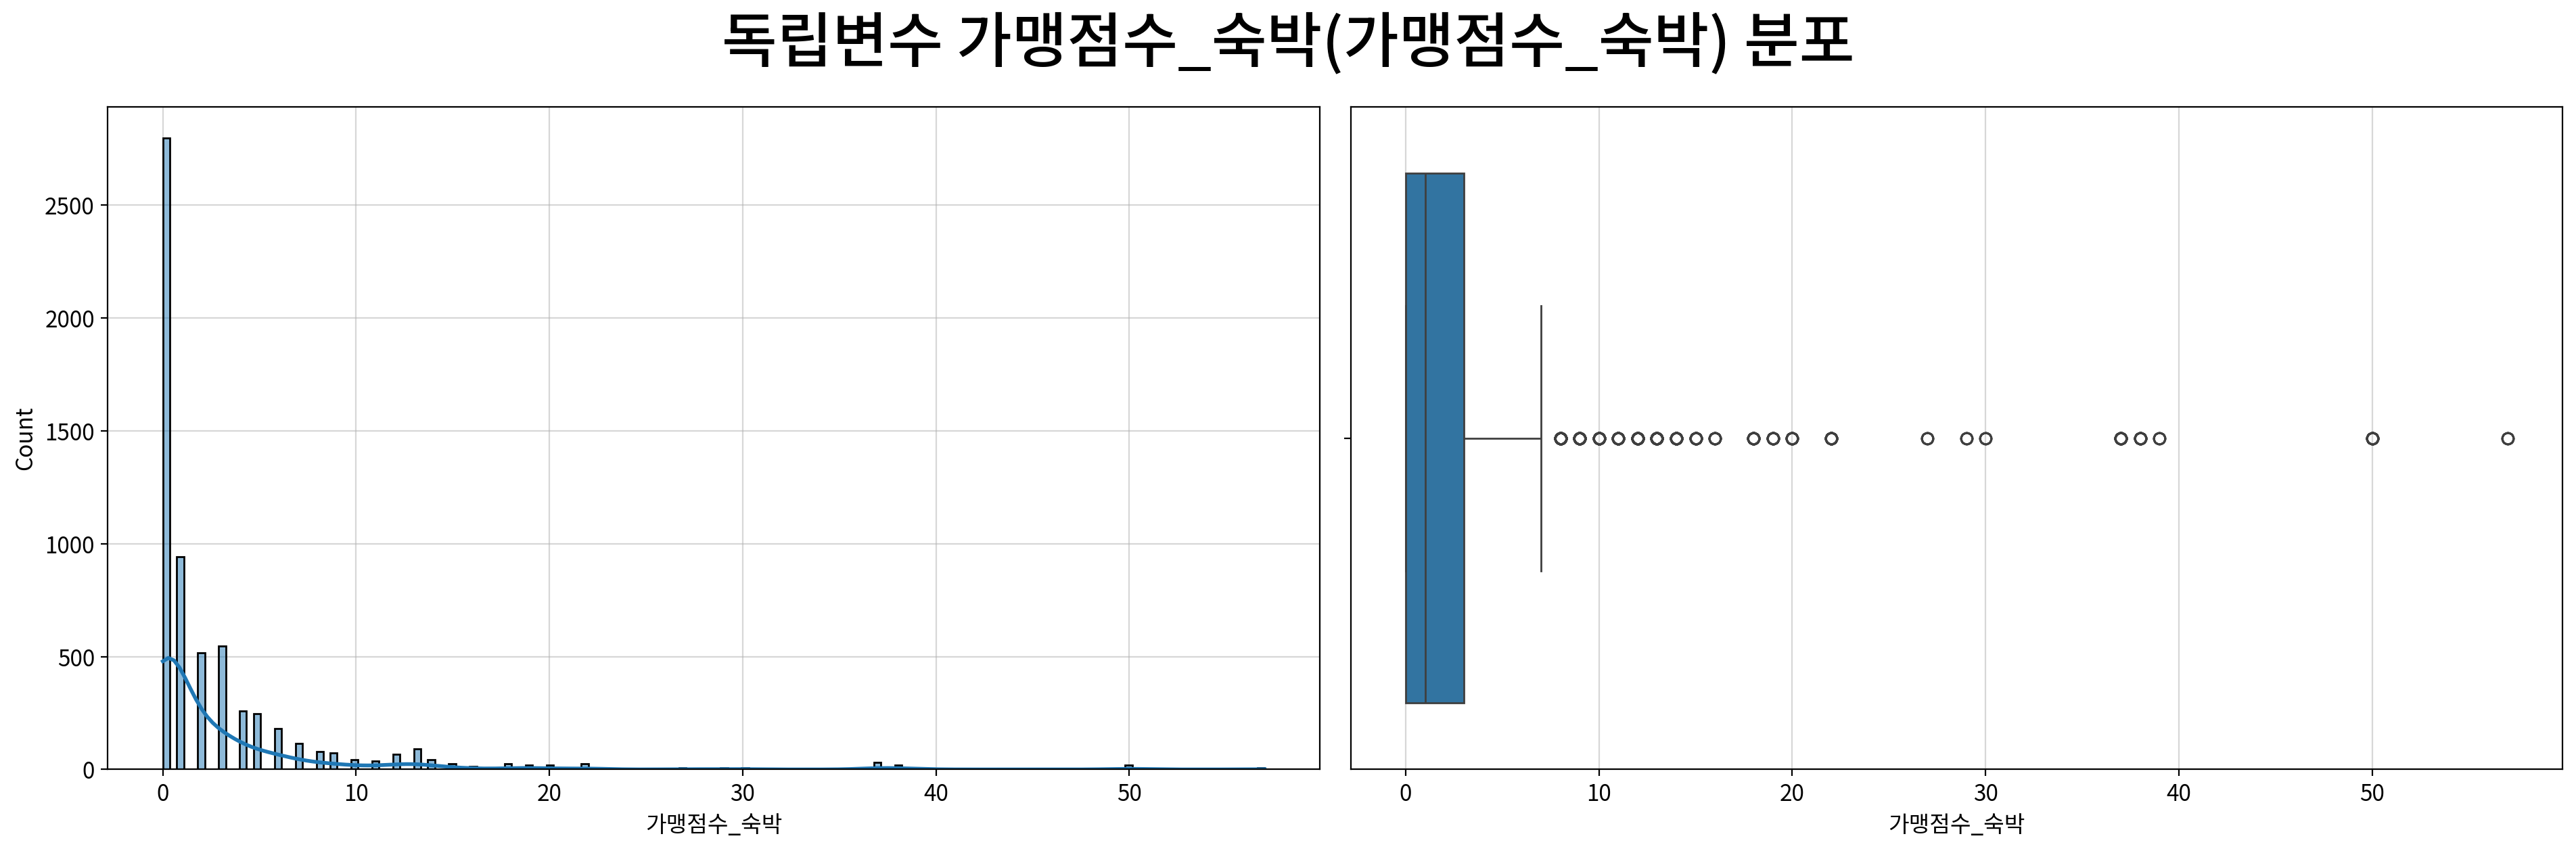

,가맹점수_숙박
count,6240
mean,2.947115
std,6.011377
min,0.0
25%,0.0
50%,1.0
75%,3.0
max,57.0
rel_diff,1.947115
rdiff_flag,large_diff


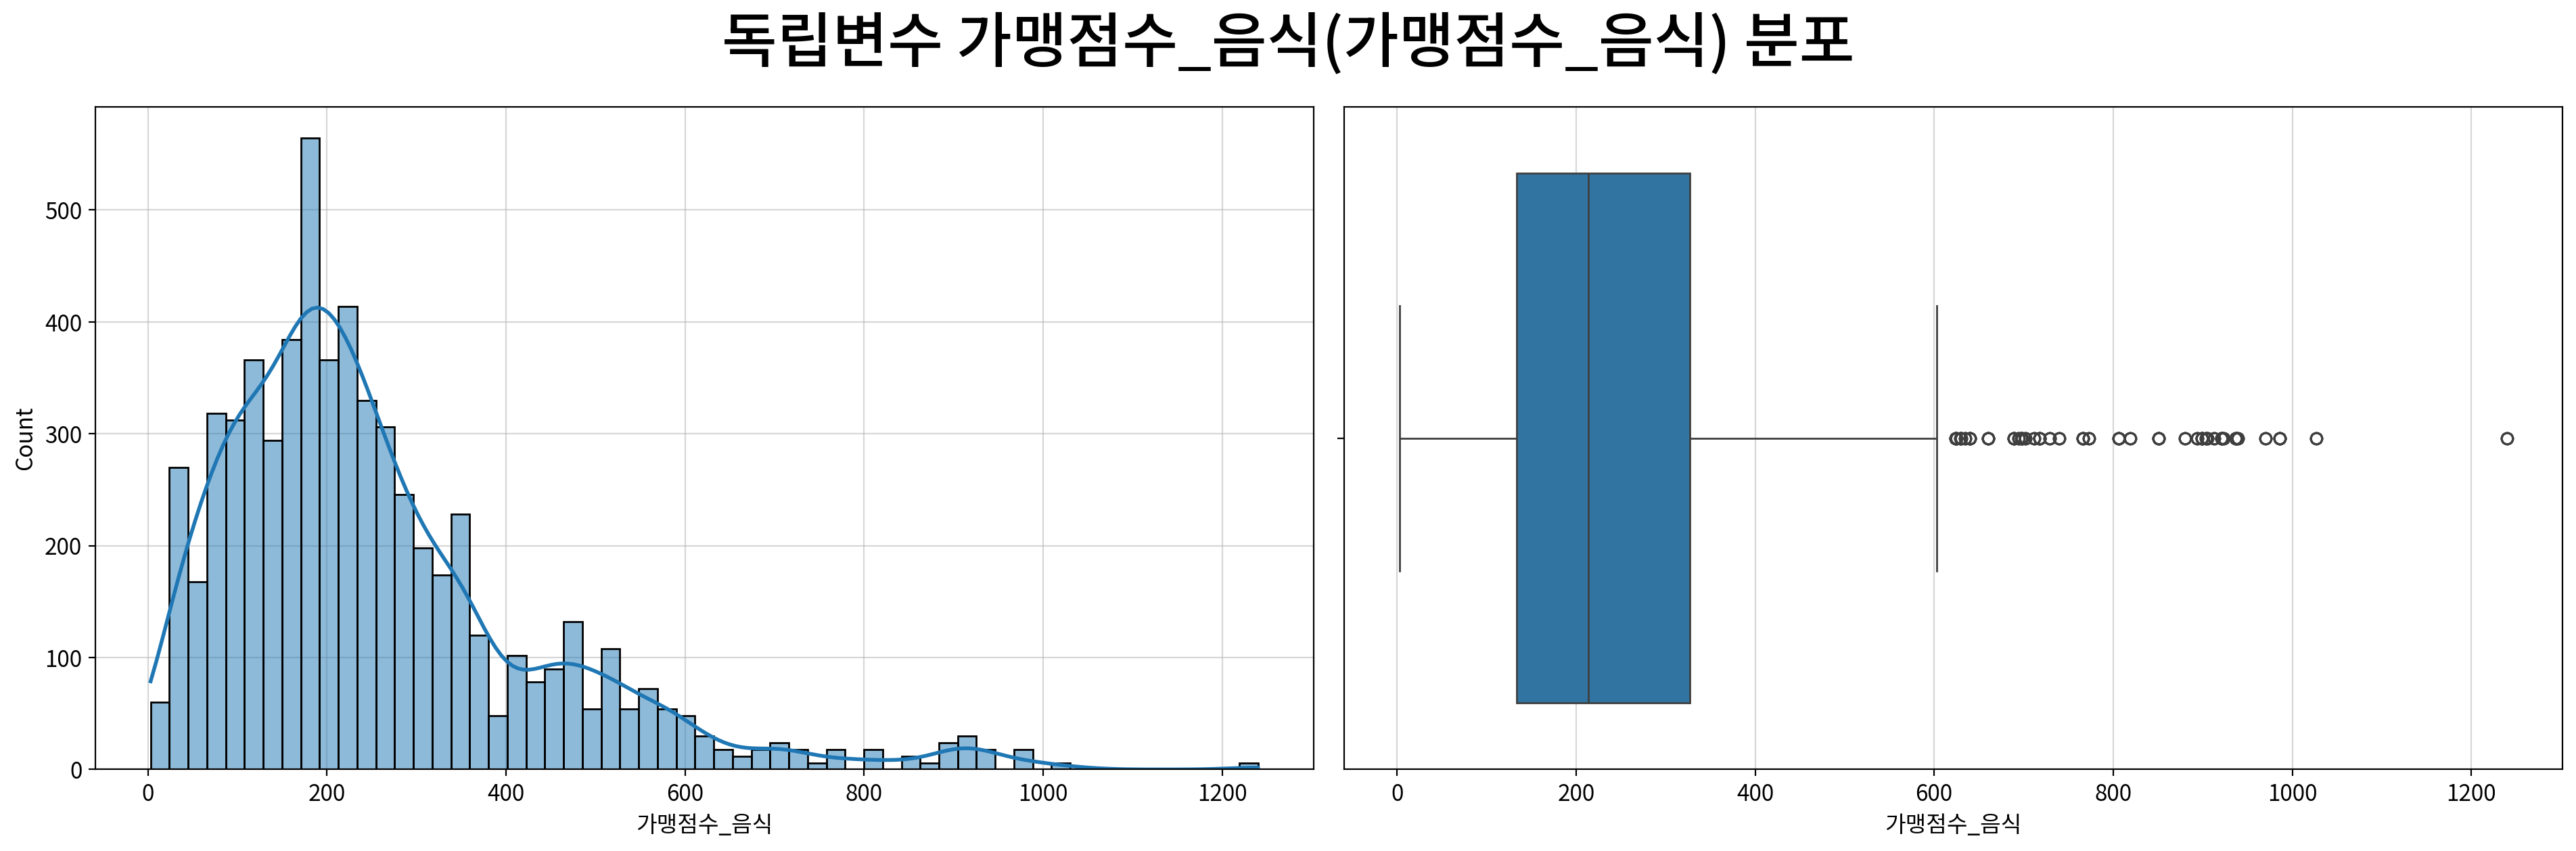

,가맹점수_음식
count,6240
mean,255.900962
std,180.953453
min,3.0
25%,133.75
50%,214.0
75%,327.25
max,1240.0
rel_diff,0.195799
rdiff_flag,diff


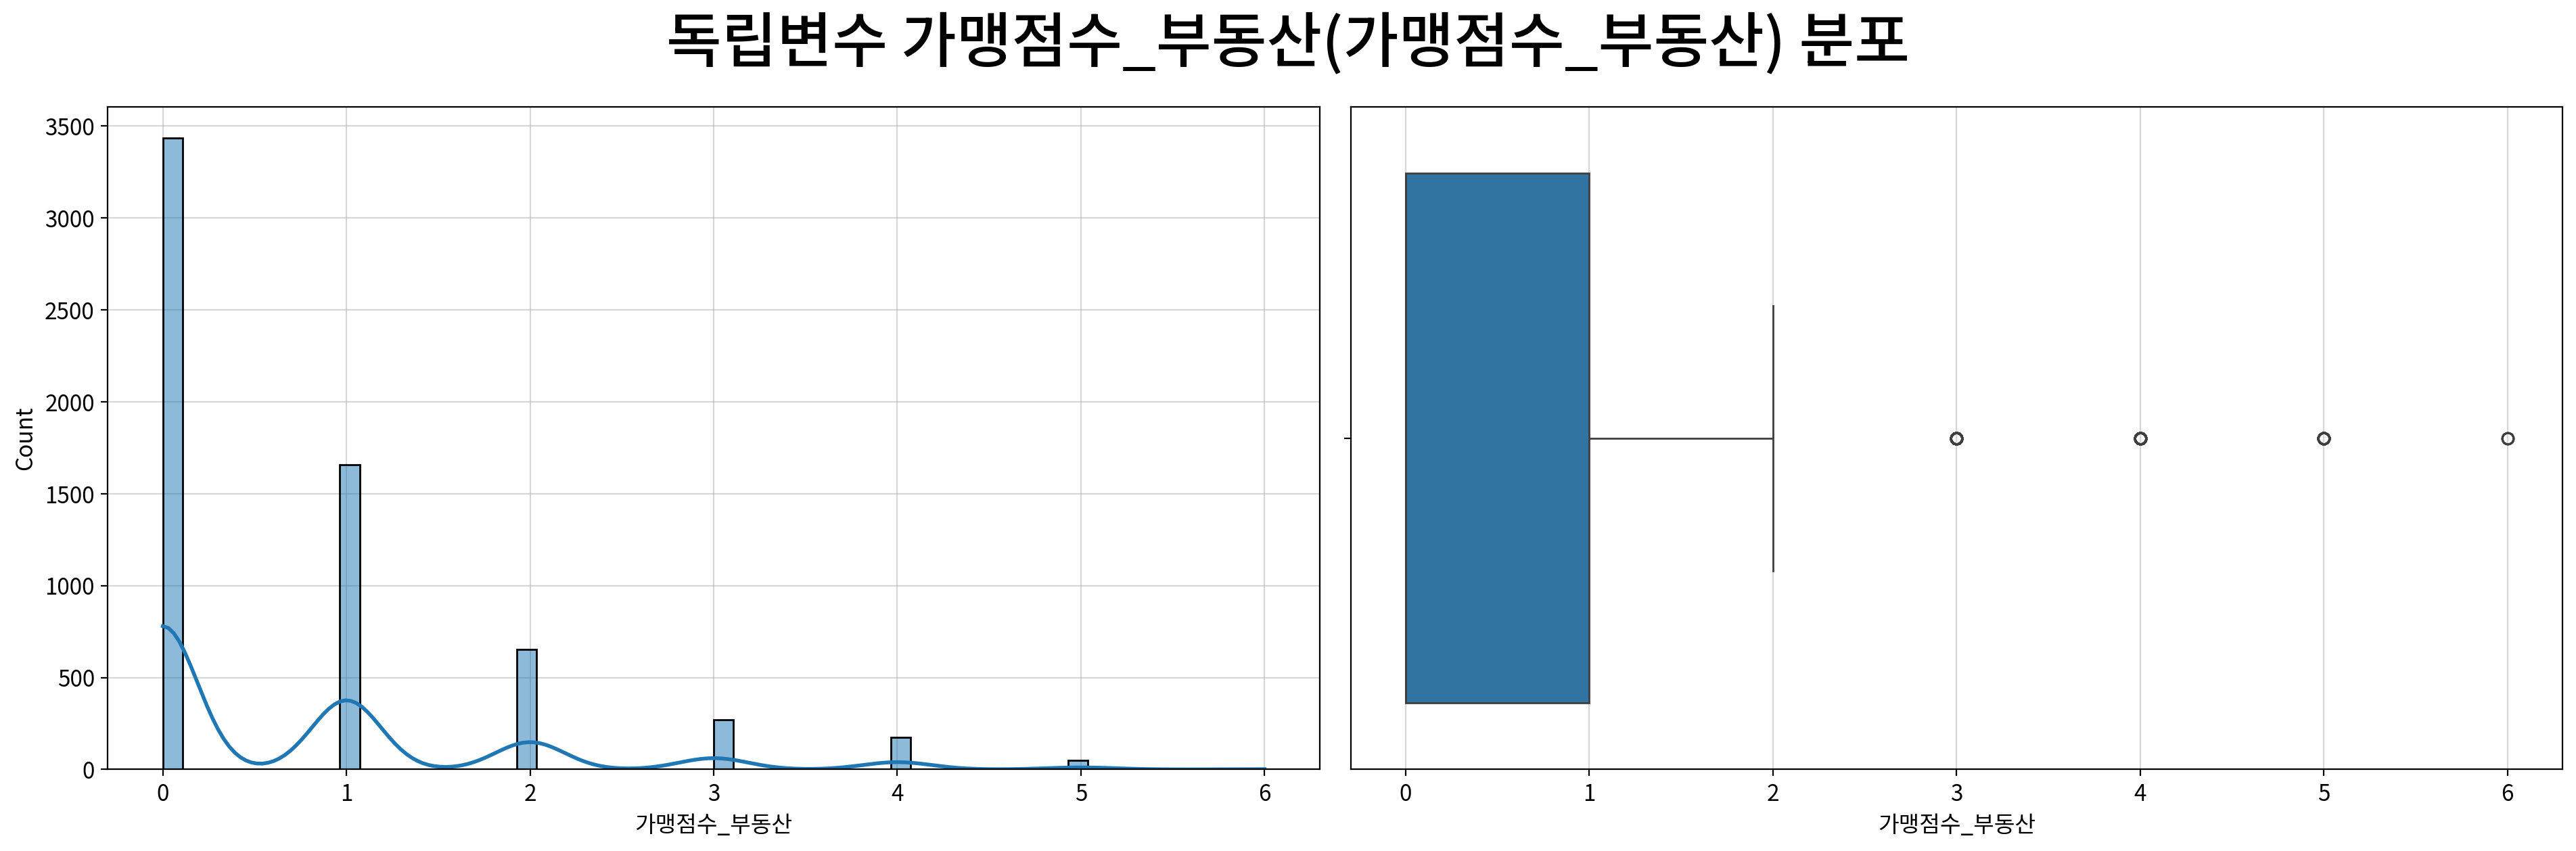

,가맹점수_부동산
count,6240
mean,0.760577
std,1.081122
min,0.0
25%,0.0
50%,0.0
75%,1.0
max,6.0
rel_diff,inf
rdiff_flag,large_diff


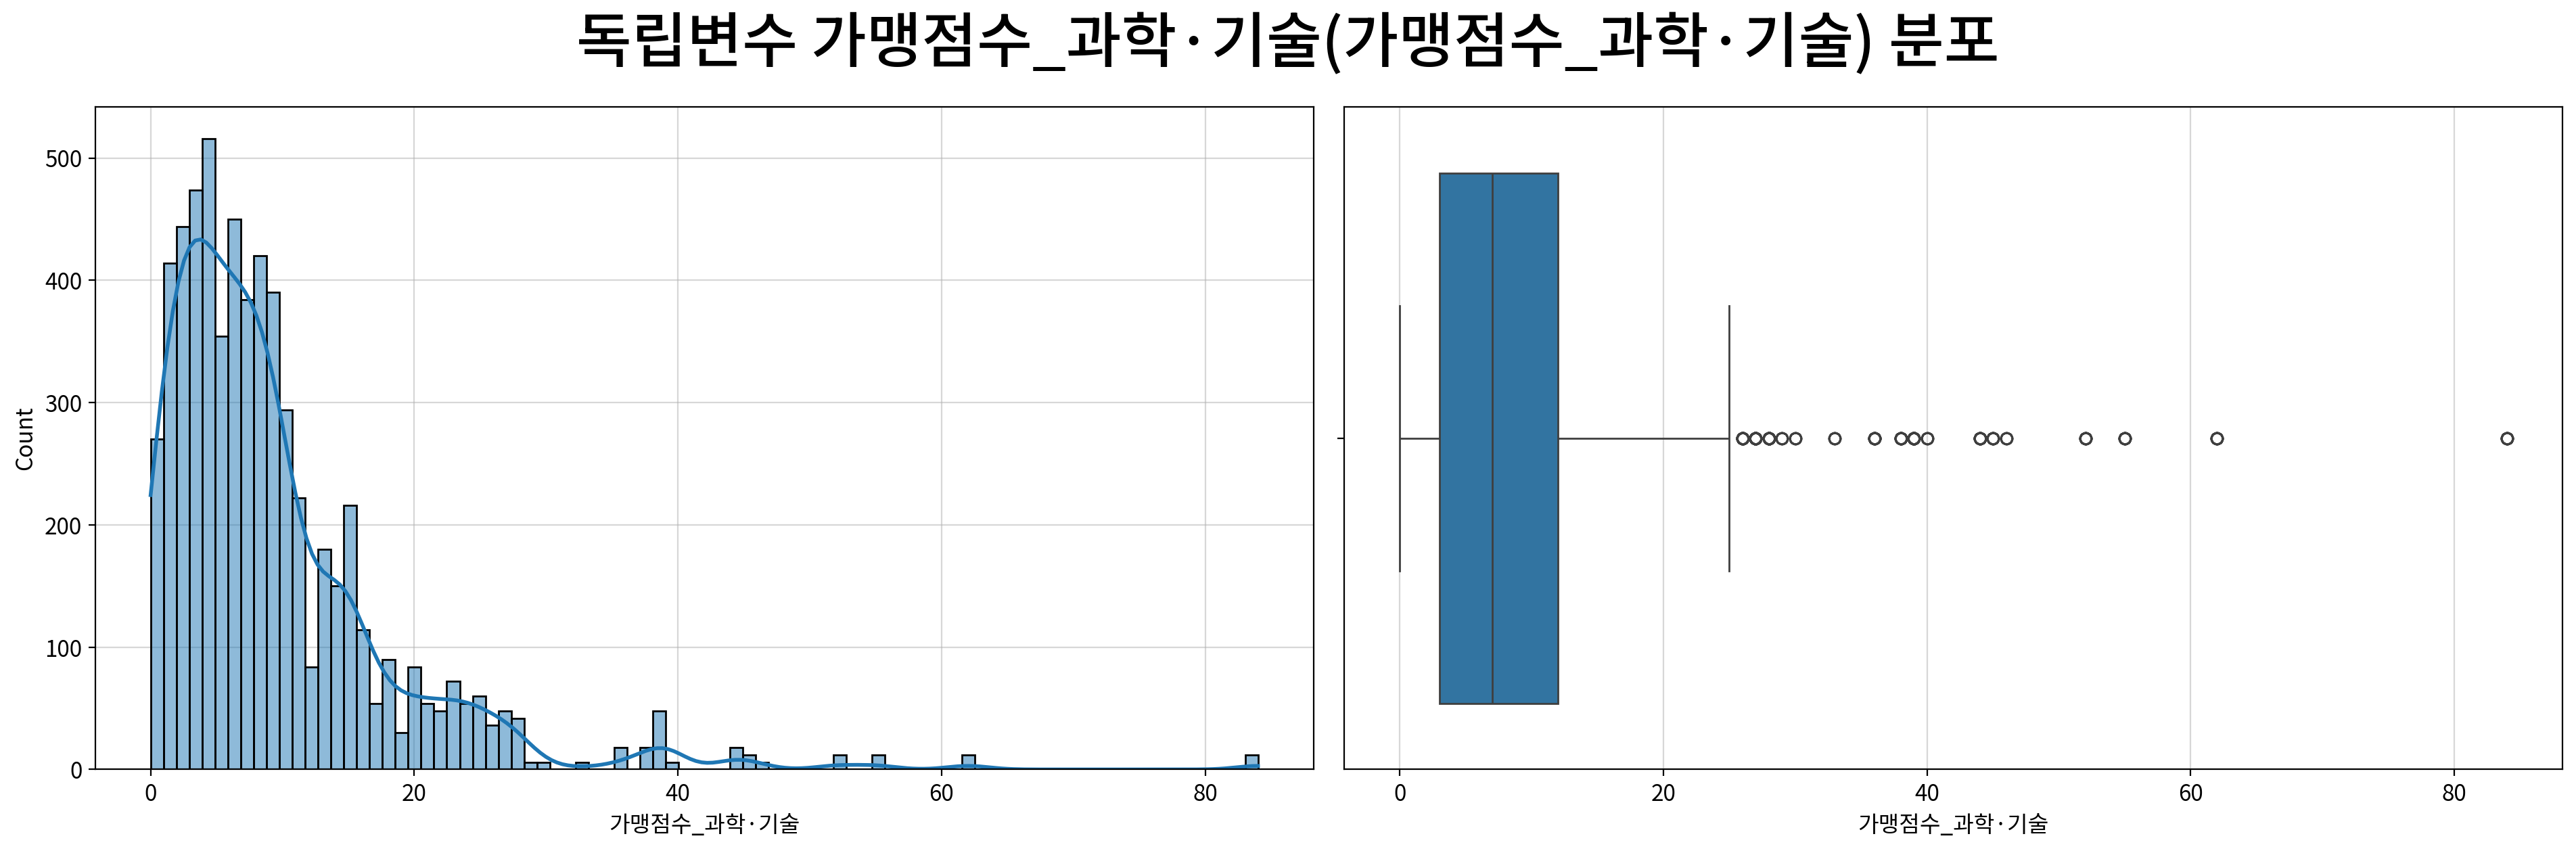

,가맹점수_과학·기술
count,6240
mean,9.325
std,9.267938
min,0.0
25%,3.0
50%,7.0
75%,12.0
max,84.0
rel_diff,0.332143
rdiff_flag,diff


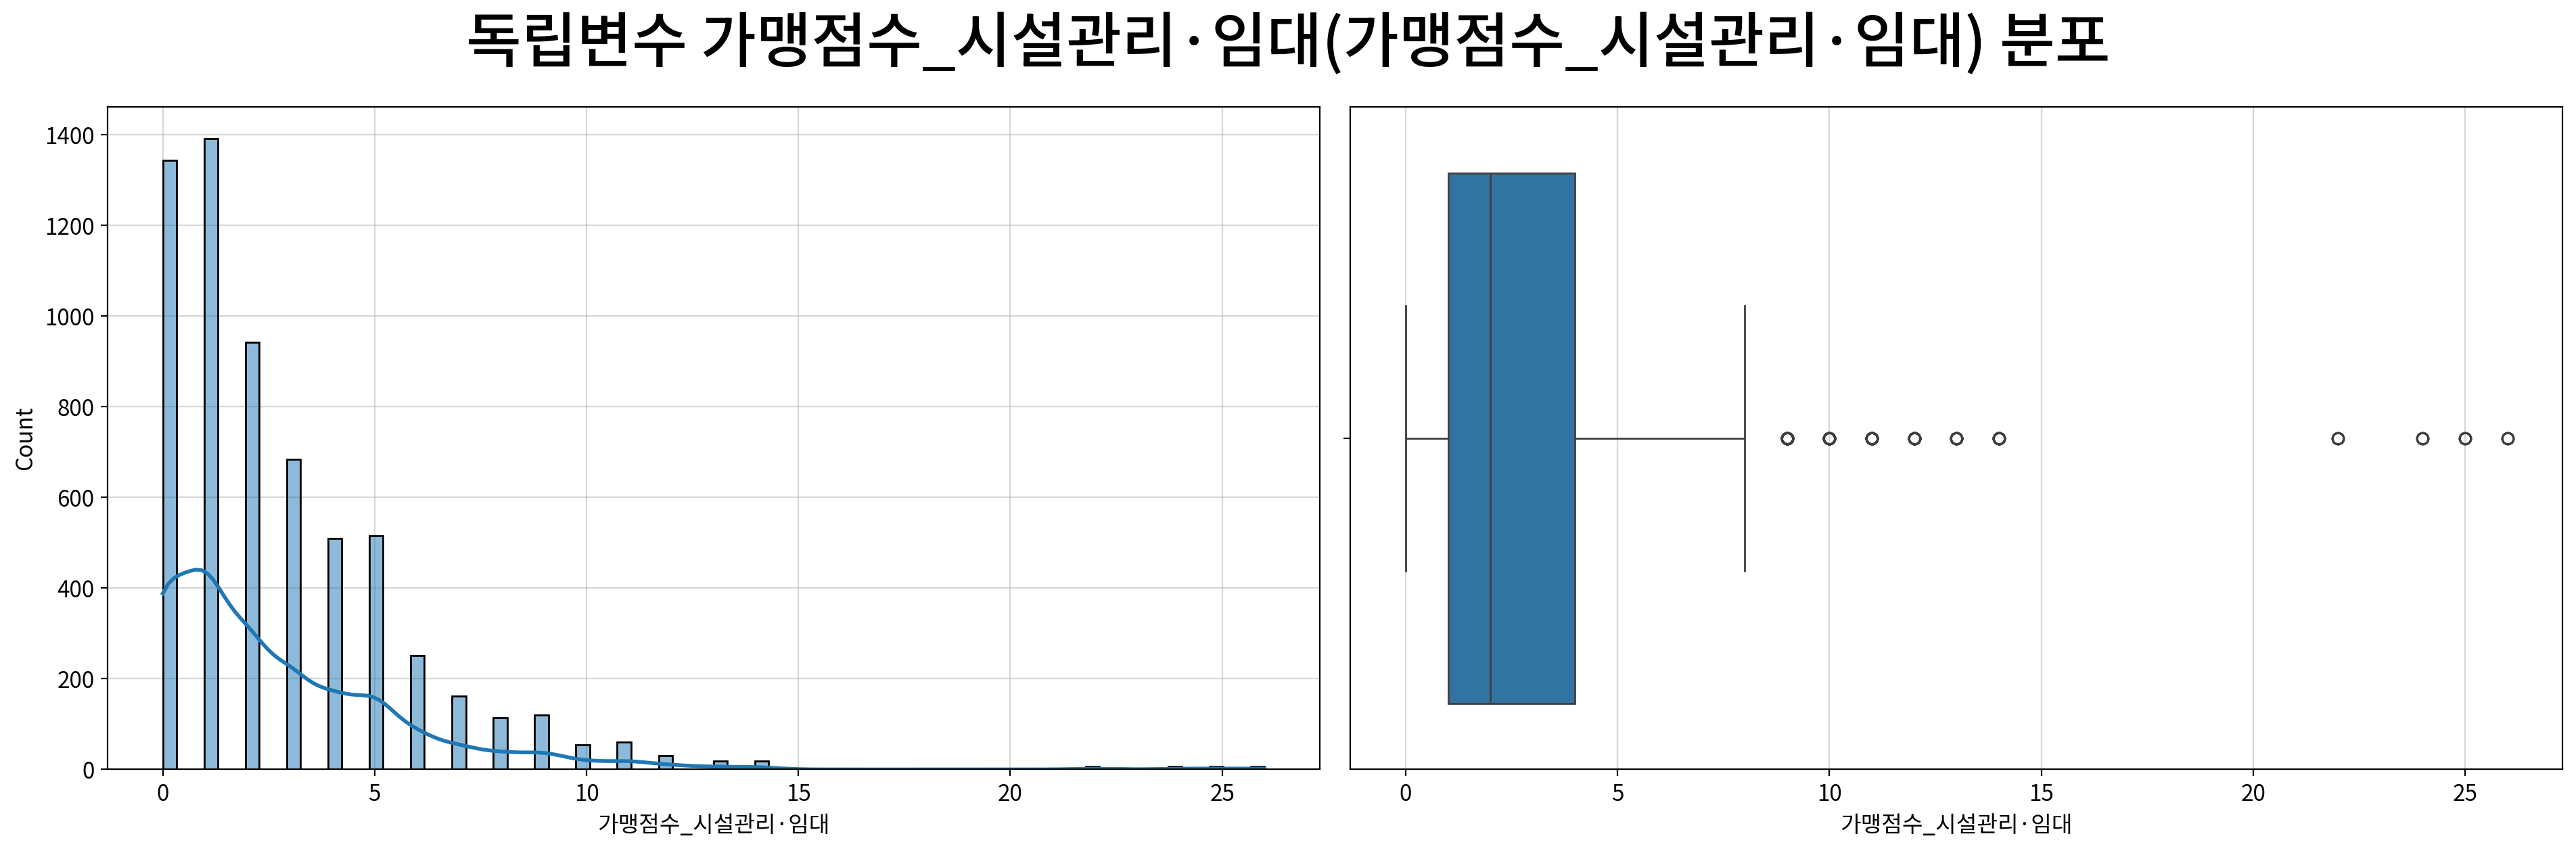

,가맹점수_시설관리·임대
count,6240
mean,2.758654
std,3.012783
min,0.0
25%,1.0
50%,2.0
75%,4.0
max,26.0
rel_diff,0.379327
rdiff_flag,diff


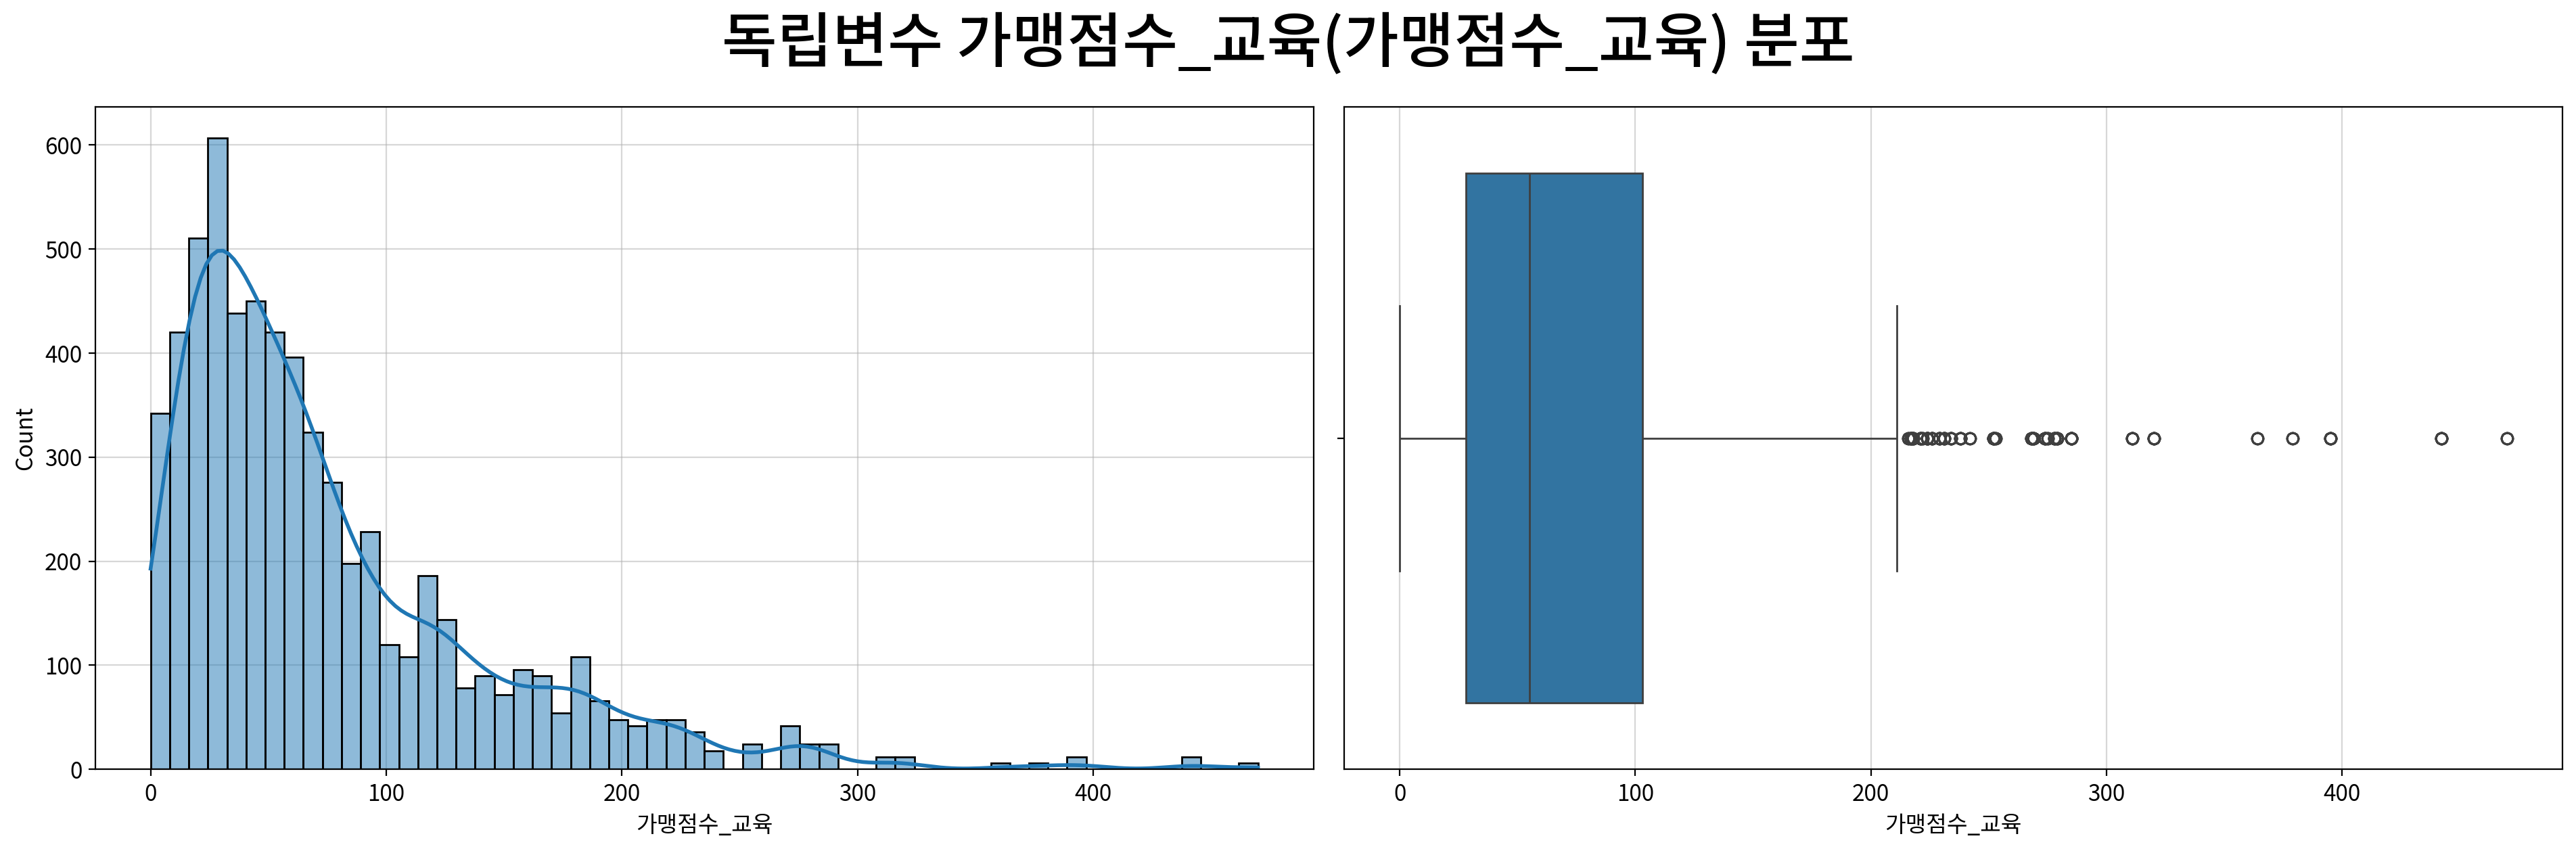

,가맹점수_교육
count,6240
mean,76.174038
std,68.417115
min,0.0
25%,28.0
50%,55.0
75%,103.0
max,470.0
rel_diff,0.384983
rdiff_flag,diff


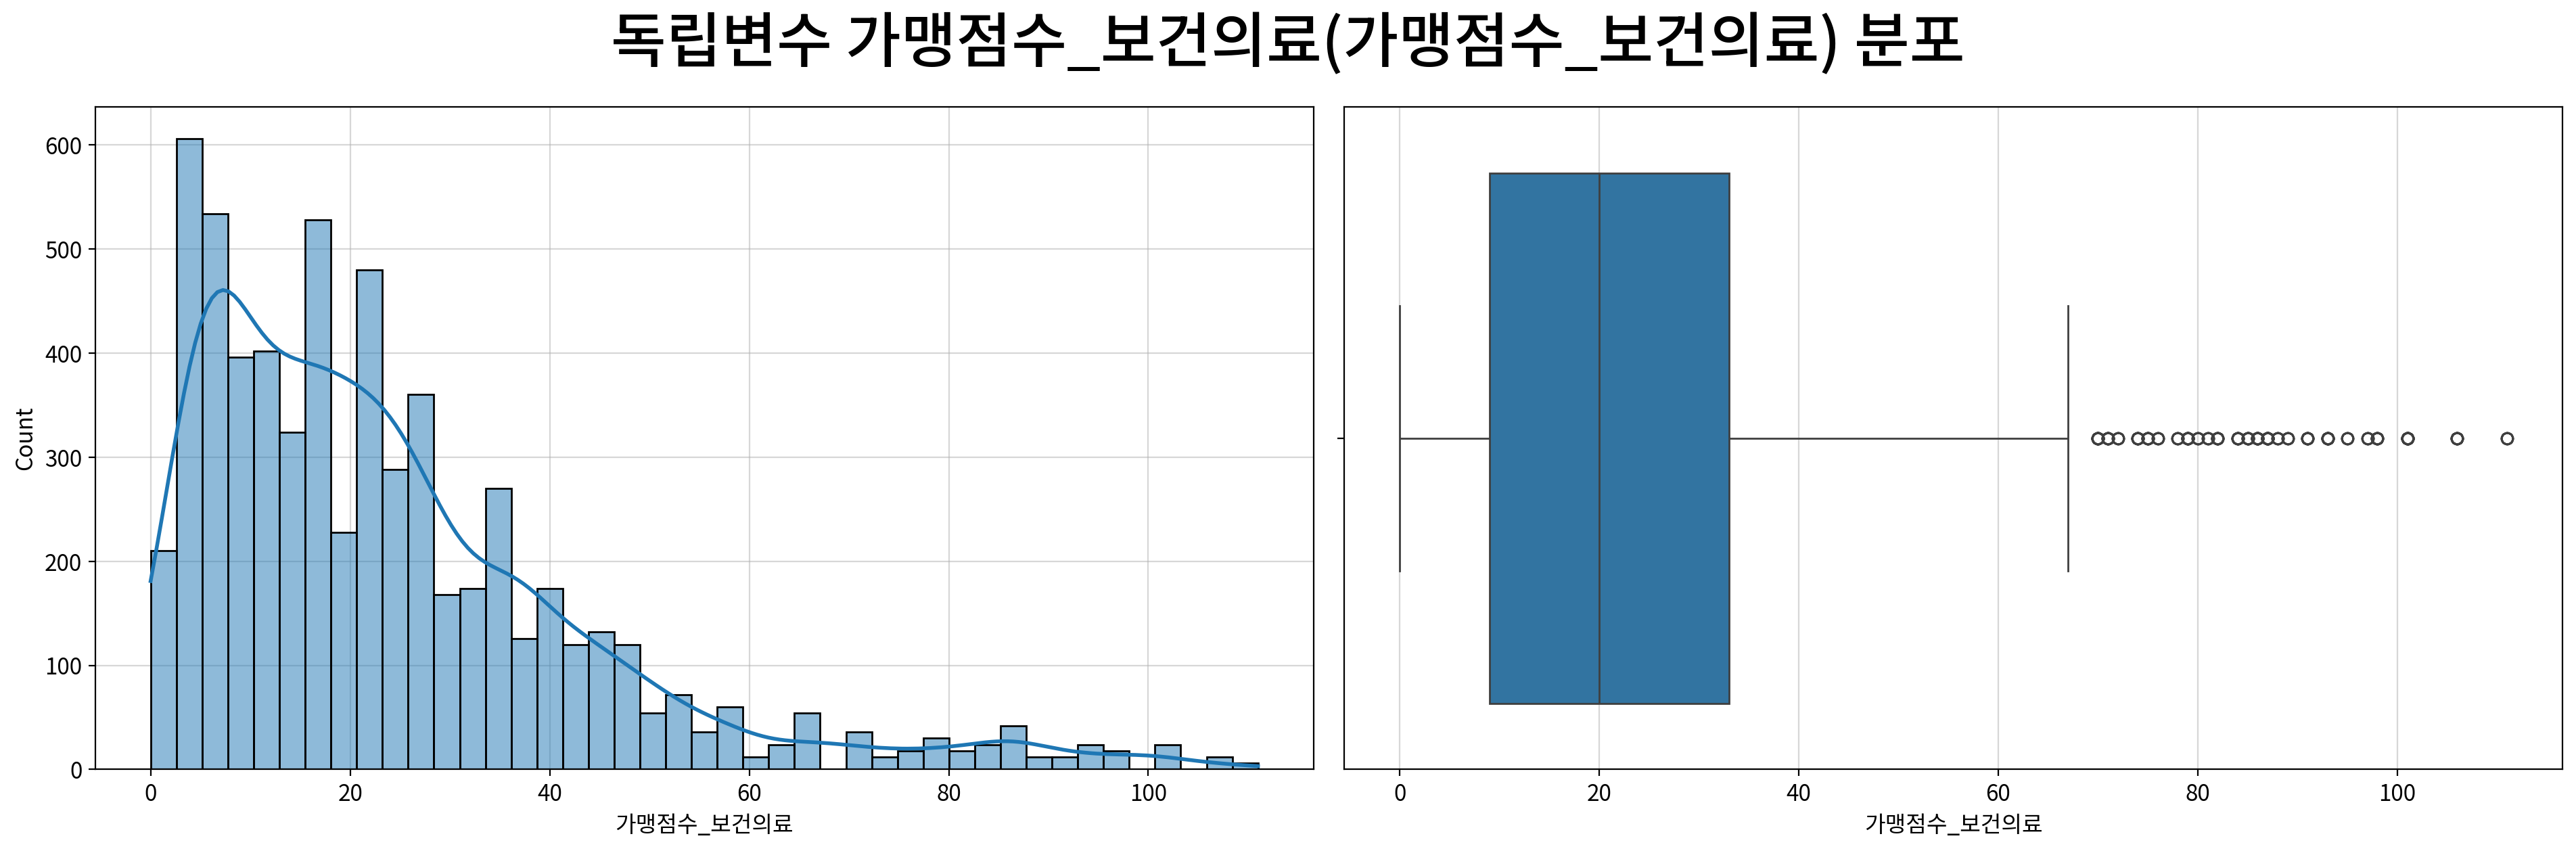

,가맹점수_보건의료
count,6240
mean,24.150962
std,20.087849
min,0.0
25%,9.0
50%,20.0
75%,33.0
max,111.0
rel_diff,0.207548
rdiff_flag,diff


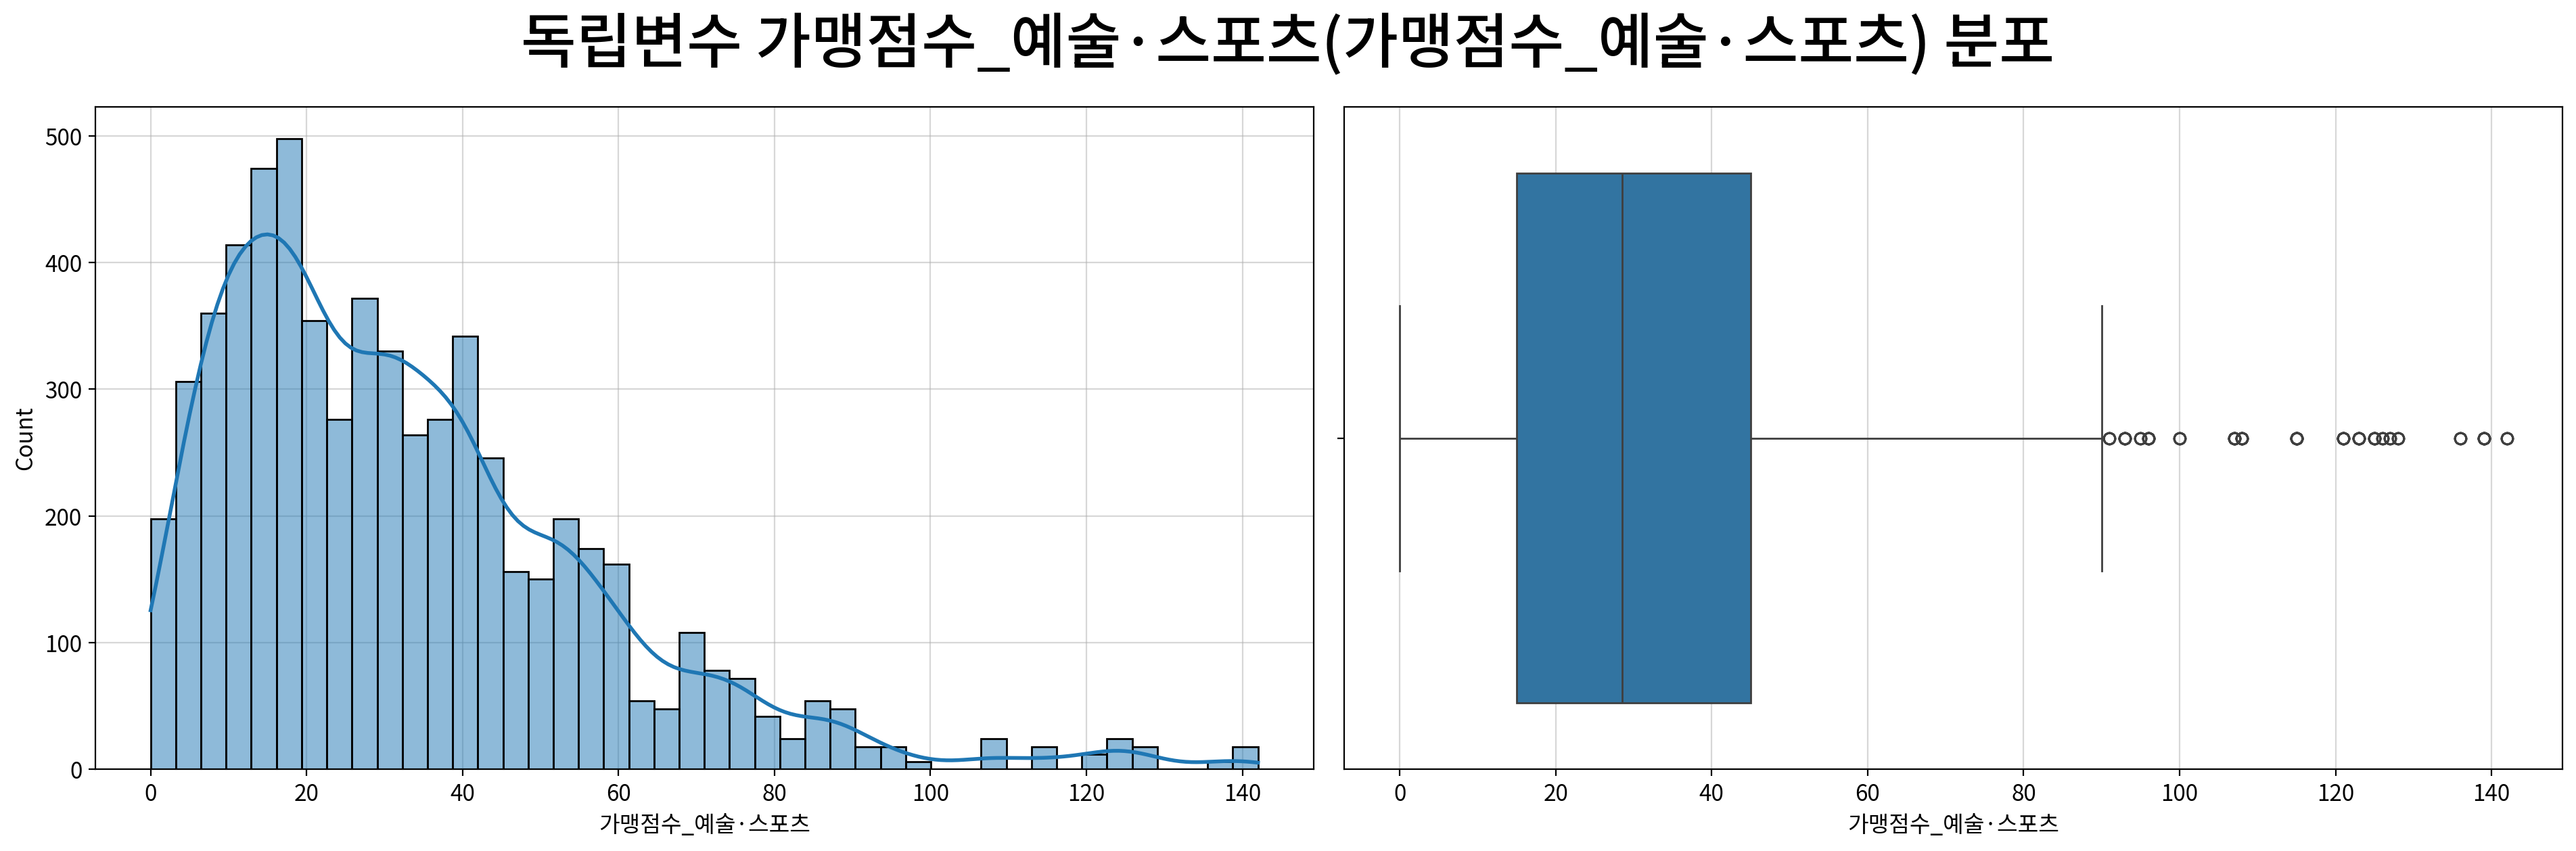

,가맹점수_예술·스포츠
count,6240
mean,33.043269
std,24.4065
min,0.0
25%,15.0
50%,28.5
75%,45.0
max,142.0
rel_diff,0.159413
rdiff_flag,diff


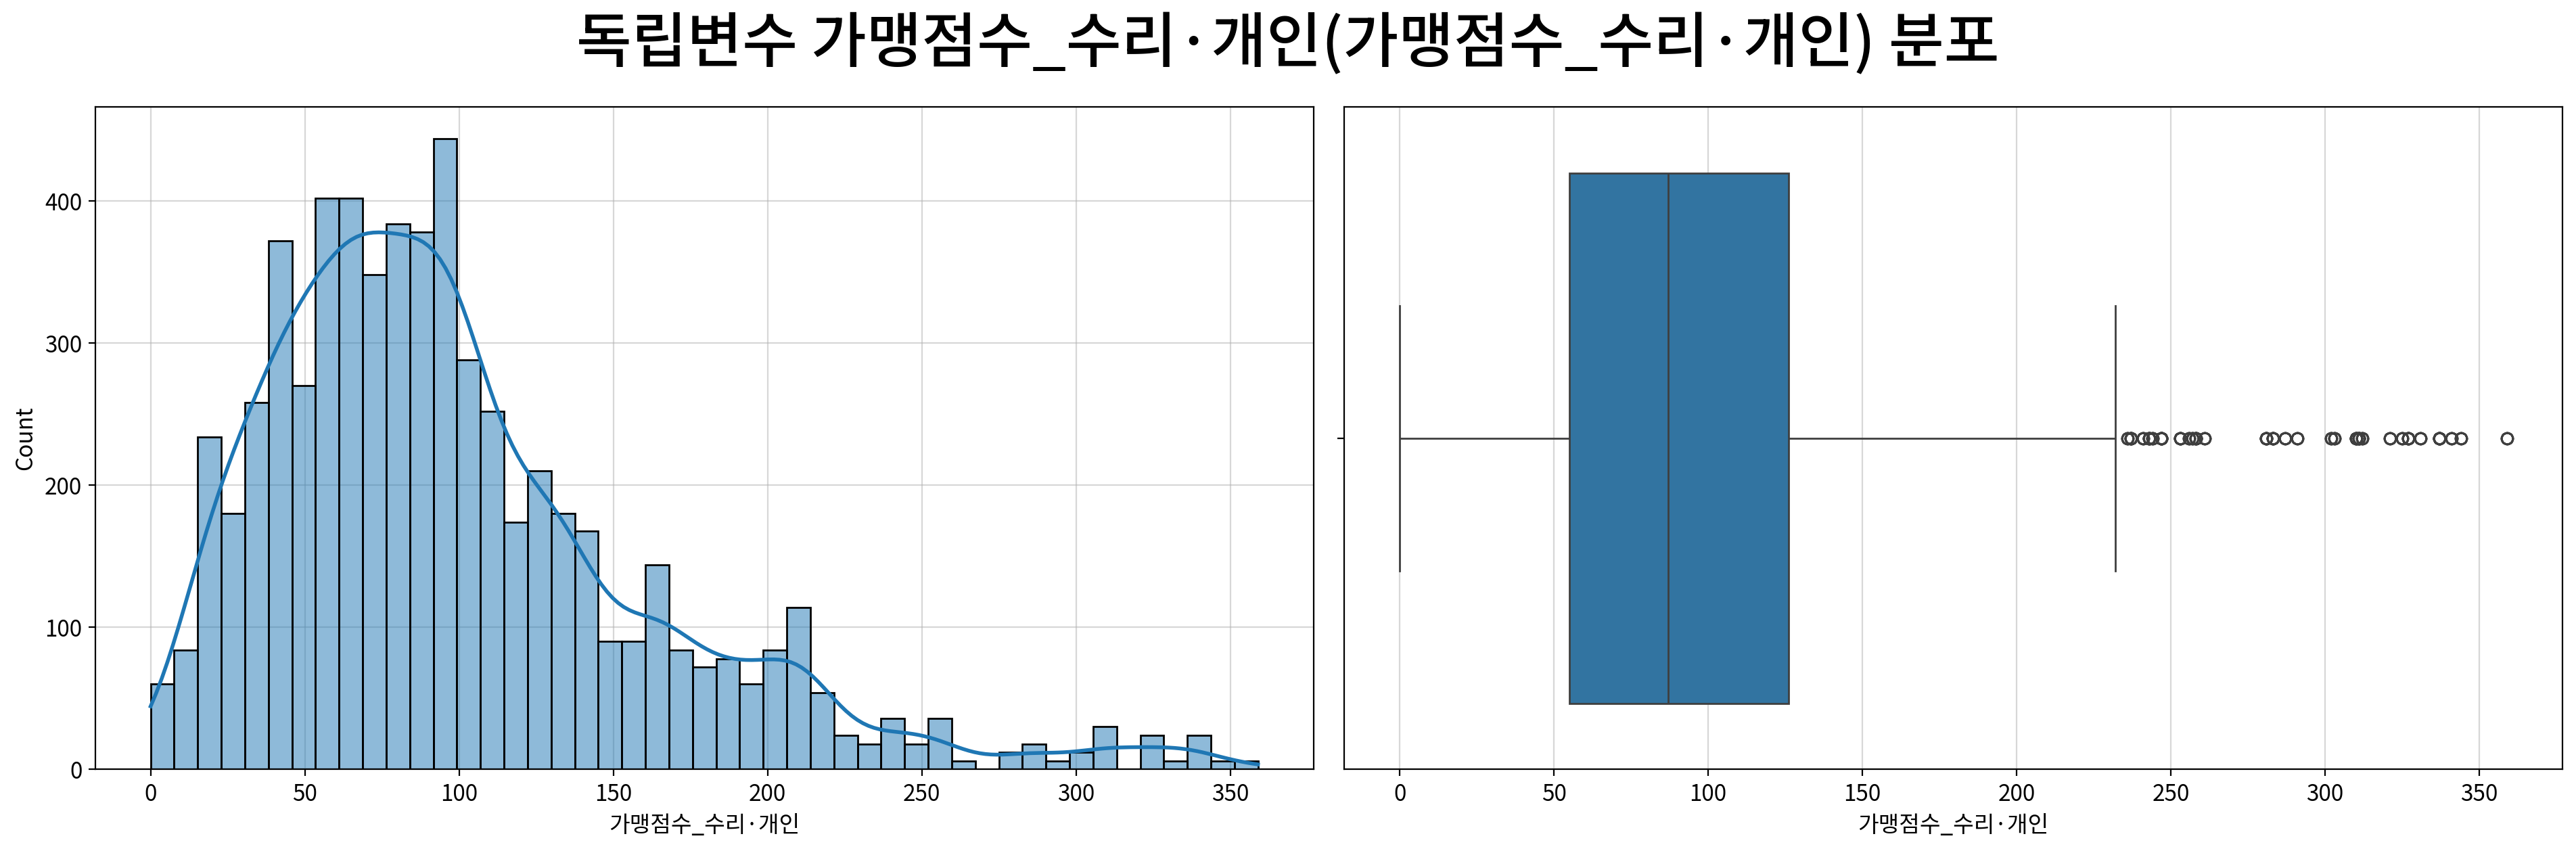

,가맹점수_수리·개인
count,6240
mean,98.939423
std,63.056567
min,0.0
25%,55.0
50%,87.0
75%,126.0
max,359.0
rel_diff,0.137235
rdiff_flag,diff


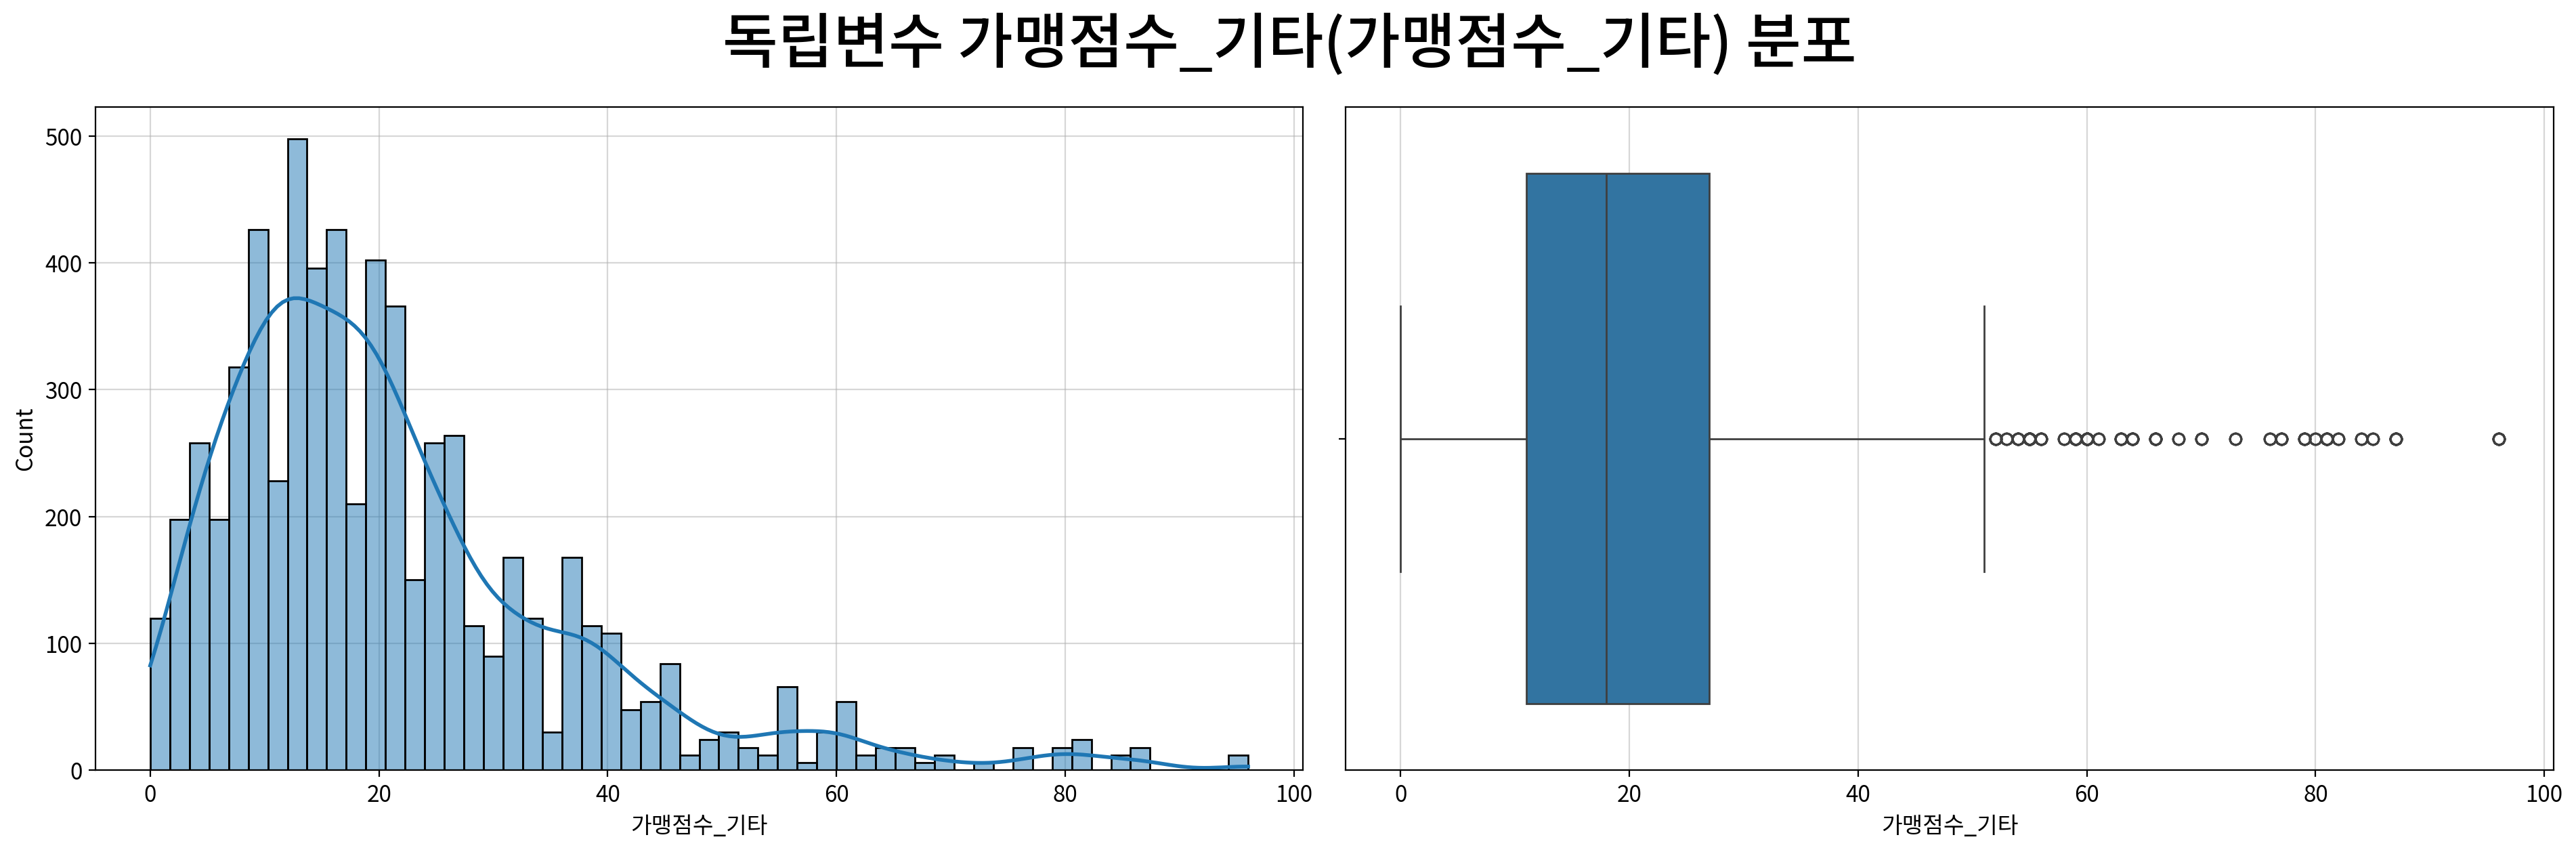

,가맹점수_기타
count,6240
mean,21.418269
std,15.802345
min,0.0
25%,11.0
50%,18.0
75%,27.0
max,96.0
rel_diff,0.189904
rdiff_flag,diff


In [17]:
# 2. 연속형 독립변수에 대한 단변량 분석

for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                           title=f"독립변수 {f}({column_means[f]}) 분포")

    my_plot.histplot(data=df3, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df3, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)

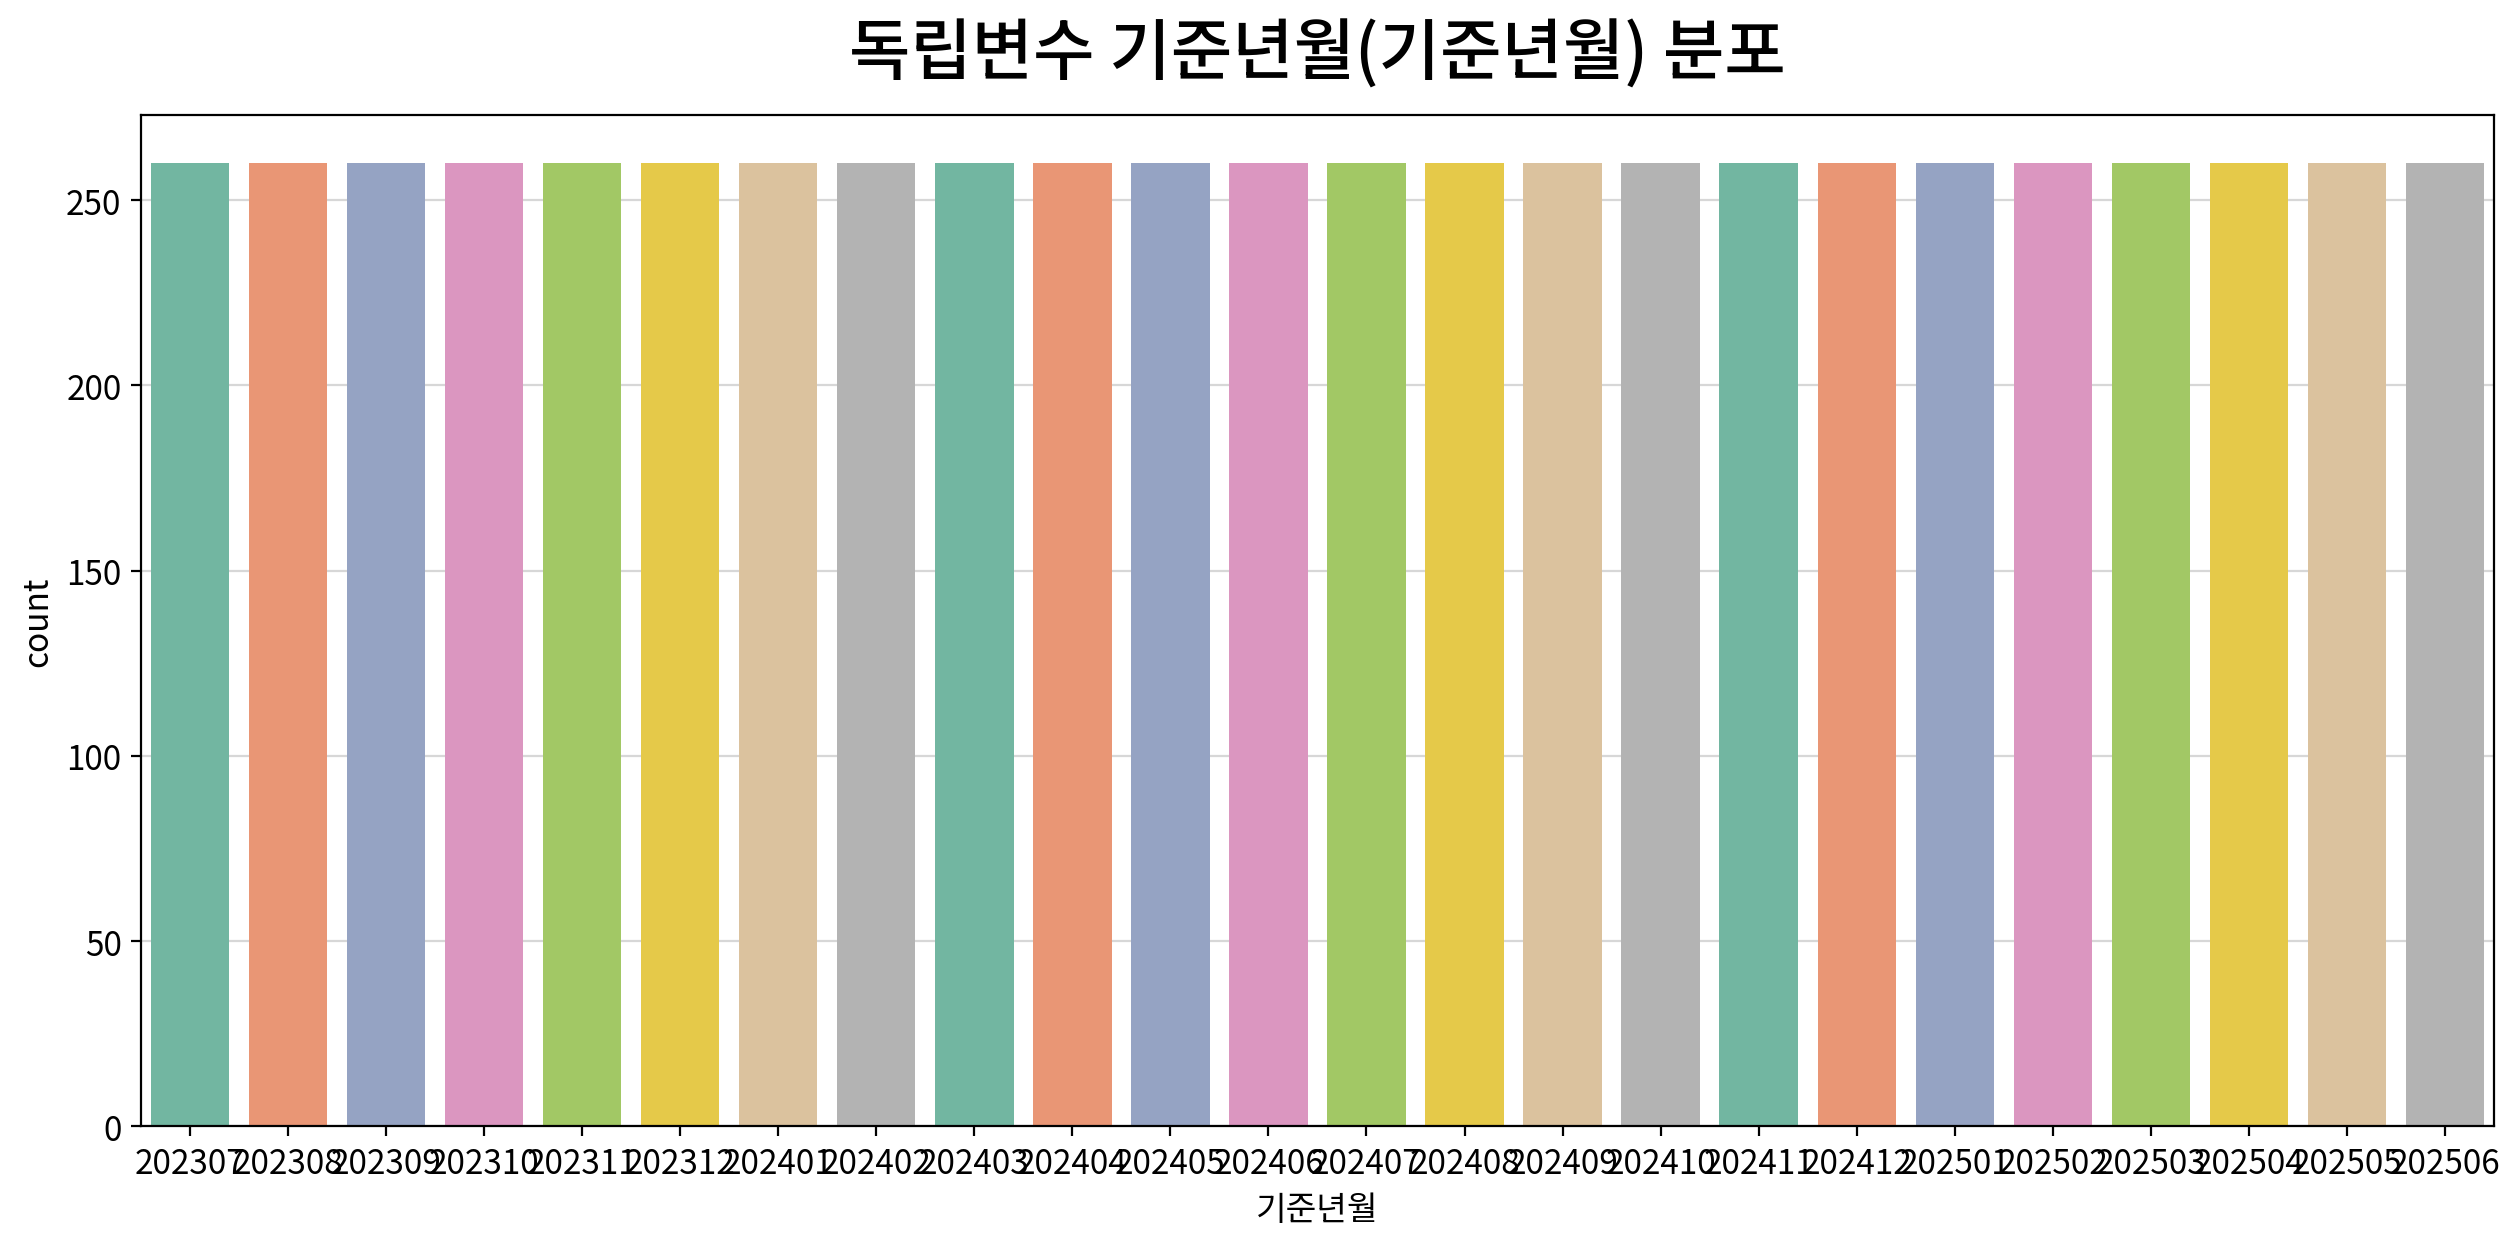

,count,unique,top,freq
기준년월,6240,24,202307,260


,빈도,비율
기준년월,,
202307,260,0.041667
202308,260,0.041667
202309,260,0.041667
202310,260,0.041667
202311,260,0.041667
202312,260,0.041667
202401,260,0.041667
202402,260,0.041667
202403,260,0.041667


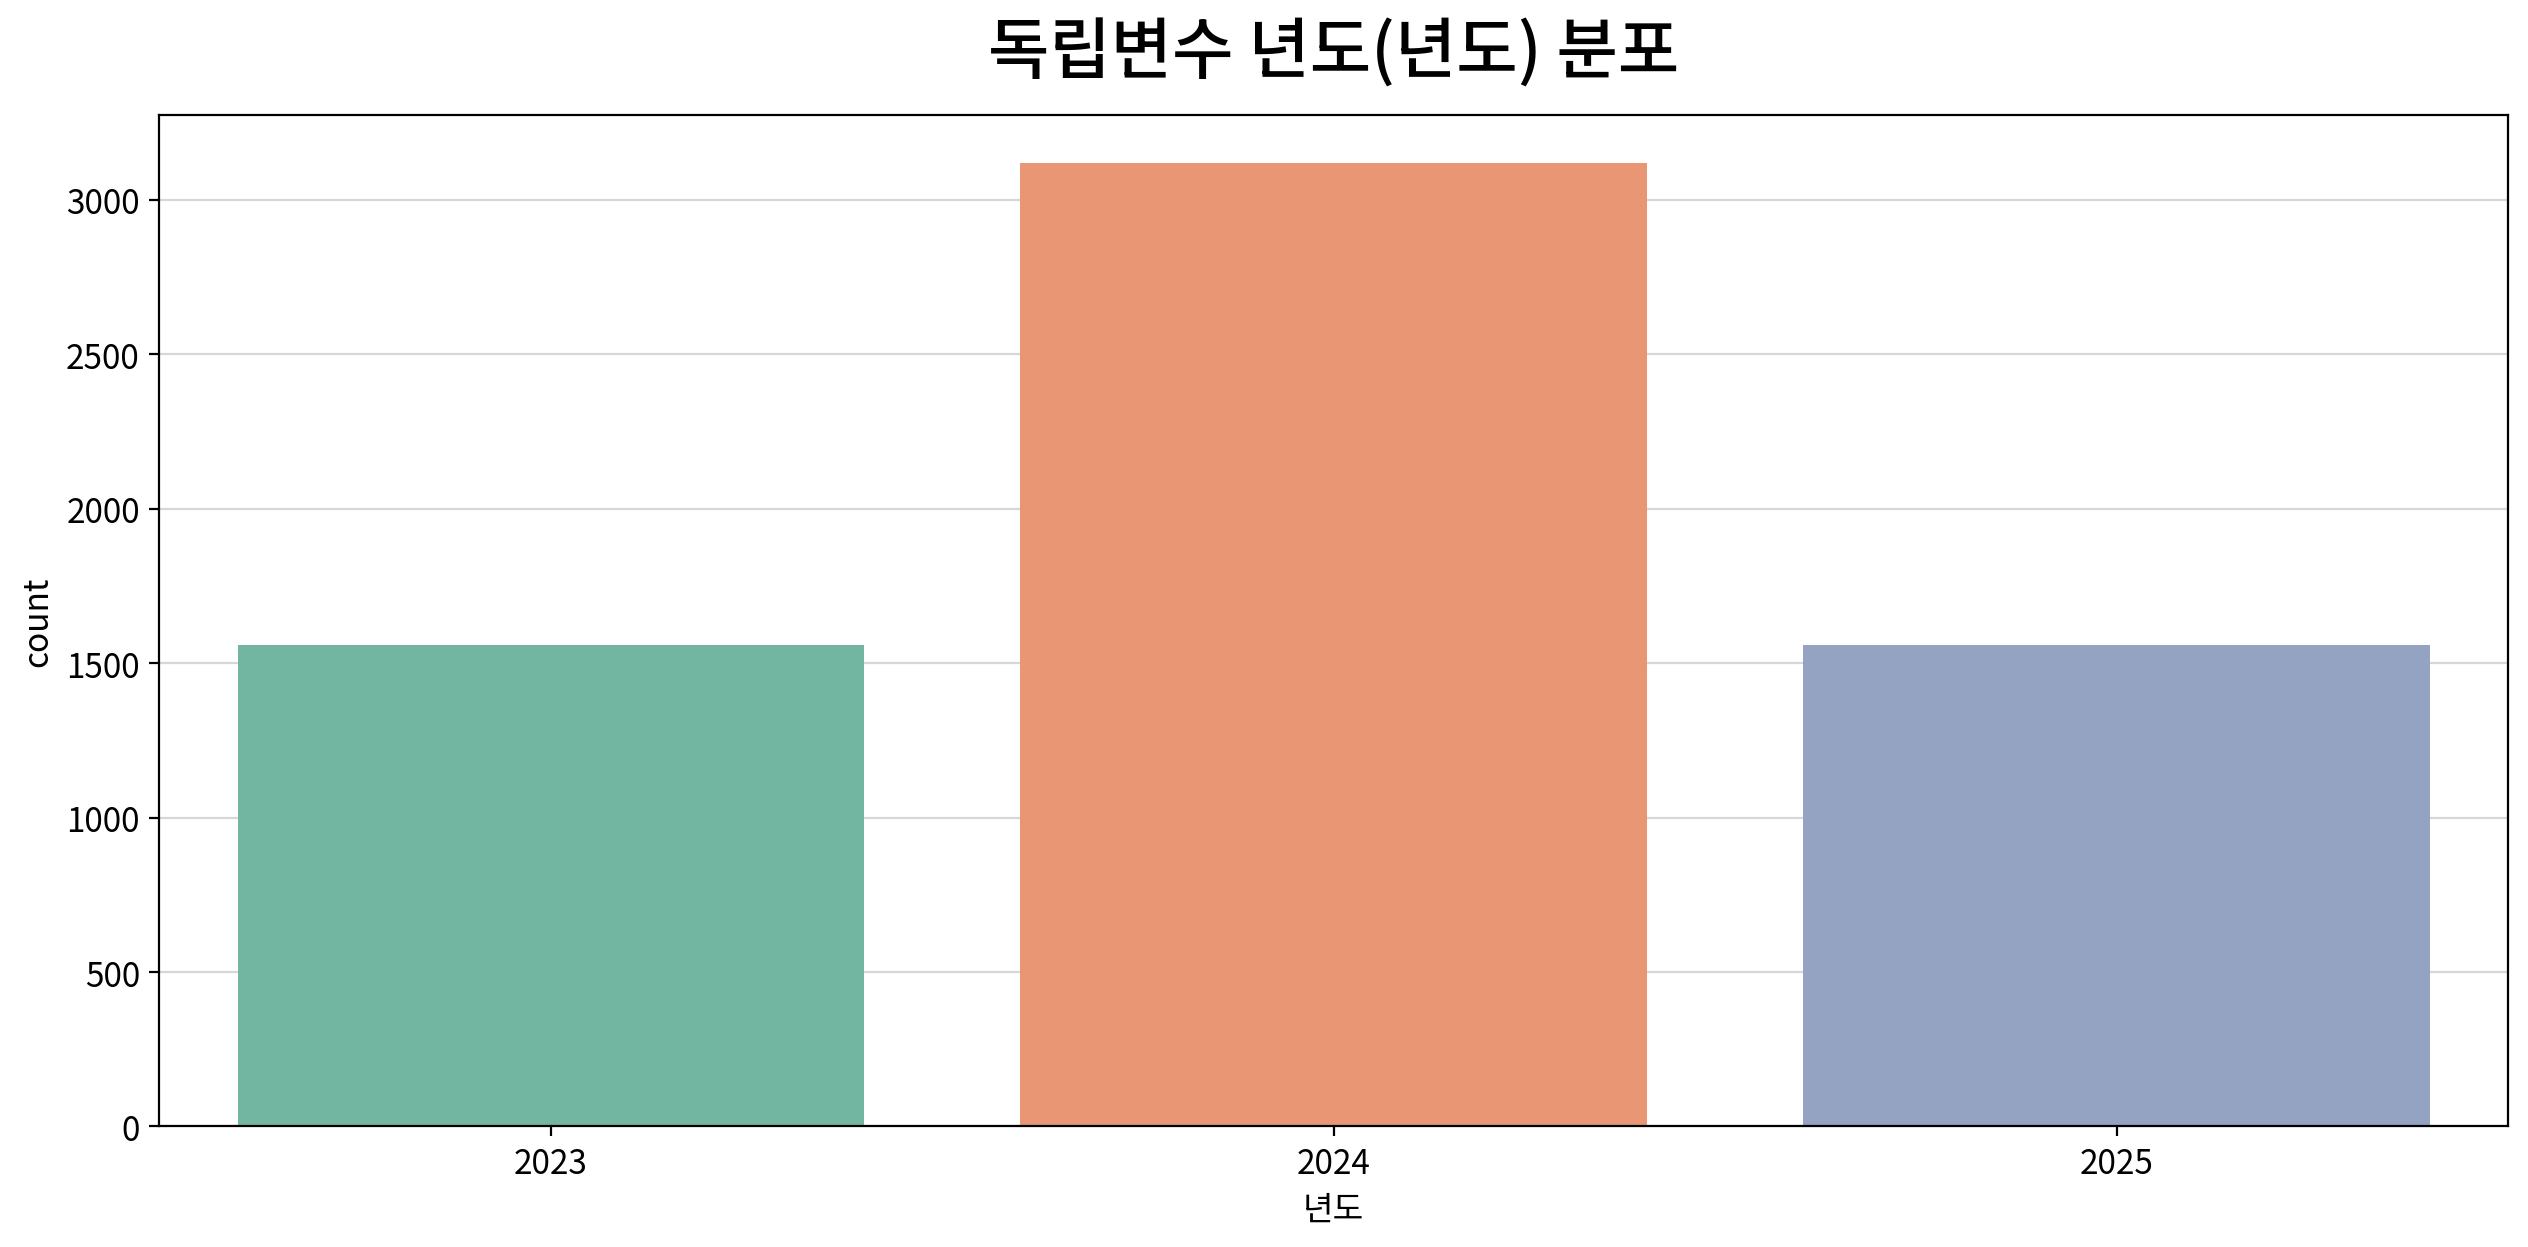

,count,unique,top,freq
년도,6240,3,2024,3120


,빈도,비율
년도,,
2024,3120,0.50
2023,1560,0.25
2025,1560,0.25


In [18]:
# 3. 명목형 독립변수에 대한 단변량 분석

for n in nominal_cols:
    # 명목형 분포는 카운트플롯으로 처리한다.
    my_plot.countplot(data=df3, x=n, hue=n, palette="Set2", title=f"독립변수 {n}({column_means[n]}) 분포")

    # 명목형 기술통계량
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq = df3[n].value_counts().rename("빈도").to_frame()
    # value_counts(normalize=True)
    # --> 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산
    freq["비율"] = df3[n].value_counts(normalize=True)
    display(freq)

In [19]:
corr_list = []

for f in continuous_cols:
    corr_list.append(my_stats.correlation(df3, x=f, y=target, plot=False))

# 11개 결과를 한 표로 합쳐 상관계수 내림차순 정렬
corr_result = concat(corr_list).sort_values("coef", ascending=False)
display(corr_result)

print("[ 상관 강도 판정별 변수 개수 ]")
print(corr_result['strength'].value_counts())

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
가맹점수_소매,매출금액,Spearman,0.2706,0.0000,Weak,True,False,False,True,True,True
가맹점수_수리·개인,매출금액,Spearman,0.2292,0.0000,Weak,True,False,False,False,True,True
가맹점수_예술·스포츠,매출금액,Spearman,0.2231,0.0000,Weak,True,False,False,True,True,True
가맹점수_음식,매출금액,Spearman,0.2120,0.0000,Weak,True,False,False,False,True,True
행정동코드,매출금액,Spearman,0.1976,0.0000,Weak,True,False,False,True,True,True
가맹점수_기타,매출금액,Spearman,0.1893,0.0000,Weak,True,False,False,False,True,True
총인구수,매출금액,Spearman,0.1856,0.0000,Weak,True,False,False,False,True,True
가맹점수_보건의료,매출금액,Spearman,0.1741,0.0000,Weak,True,False,False,False,True,True
가맹점수_부동산,매출금액,Spearman,0.1476,0.0000,Weak,True,False,False,False,True,True


[ 상관 강도 판정별 변수 개수 ]
strength
Weak    14
Name: count, dtype: int64


In [20]:
# 2. T-Test(x: 2집단 명목형 독립변수 -> y: 종속변수)
for n in nominal_cols:
    # 2개의 고유값을 가지는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df3[n].unique()) == 2:
        # 빈 줄 출력용
        print()

        # 분석 단위 제목 출력
        display(Markdown(f"#### 🧪 {n}({column_means[n]}) → {target}"))

        # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
        wide_df = my_prep.long2wide(df3, hue=n, values=target)
        display(my_stats.test_independent(wide_df,
                                          group1=wide_df.columns[0], group2=wide_df.columns[1]))

In [21]:
# 3. ANOVA(x: 3집단 명목형 독립변수 -> y: 종속변수) 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정
for n in nominal_cols:
    # 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df3[n].unique()) >= 3:
        print()  # 빈 줄 출력용

        # 분석 단위 제목 출력
        display(Markdown(f"#### 🧪 {n}({column_means[n]}) → {target}"))

        # origin이 아닌 df를 사용해야 서열척도로 지정한 범주 순서가 반영된다.
        display(my_stats.anova_oneway(df3, y=target, between=n))
        display(my_stats.posthoc_oneway(df3, y=target, between=n, plot=False))

#### 🧪 기준년월(기준년월) → 매출금액

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,기준년월,23,2251.454328,8.09185,3.009382e-26,0.071184,Medium


비교한 조합 쌍: 276개
유의한 쌍: 24개
평균 차이가 가장 큰 쌍: (202307) vs (202403) → 차이 103603354.996, 효과크기 Large, p-value 0.000
평균 차이가 가장 작은 쌍: (202401) vs (202412) → 차이 35515.835, 효과크기 Negligible, p-value 1.000


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,202307,202308,1.123976e+08,2.599843e+07,8.639917e+07,8.293247e+06,10.418015,363.214795,2.673417e-13,0.912397,True,Large
1,Games-Howell,202307,202309,1.123976e+08,1.788331e+07,9.451430e+07,9.178194e+06,10.297701,461.628656,1.989520e-13,0.901860,True,Large
2,Games-Howell,202307,202310,1.123976e+08,1.733555e+07,9.506206e+07,9.038042e+06,10.517993,449.118845,0.000000e+00,0.921153,True,Large
3,Games-Howell,202307,202311,1.123976e+08,1.503141e+07,9.736620e+07,8.689320e+06,11.205272,412.553625,2.781109e-13,0.981344,True,Large
4,Games-Howell,202307,202312,1.123976e+08,1.628501e+07,9.611259e+07,8.921415e+06,10.773245,437.723671,8.248957e-14,0.943507,True,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,Games-Howell,202503,202505,1.591754e+07,1.291459e+07,3.002944e+06,6.353280e+06,0.472660,485.774413,1.000000e+00,0.041395,False,Negligible
272,Games-Howell,202503,202506,1.591754e+07,1.382855e+07,2.088988e+06,6.565878e+06,0.318158,502.188016,1.000000e+00,0.027864,False,Negligible
273,Games-Howell,202504,202505,1.223843e+07,1.291459e+07,-6.761597e+05,5.424239e+06,-0.124655,517.822006,1.000000e+00,-0.010917,False,Negligible
274,Games-Howell,202504,202506,1.223843e+07,1.382855e+07,-1.590115e+06,5.671768e+06,-0.280356,512.631263,1.000000e+00,-0.024553,False,Negligible


#### 🧪 년도(년도) → 매출금액

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,년도,2,2979.625134,34.042486,2.409462e-15,0.014328,Small


비교한 조합 쌍: 3개
유의한 쌍: 2개
평균 차이가 가장 큰 쌍: (2023) vs (2024) → 차이 20877291.394, 효과크기 Small, p-value 0.000
평균 차이가 가장 작은 쌍: (2024) vs (2025) → 차이 1330465.262, 효과크기 Negligible, p-value 0.816


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,2023,2024,3.415522e+07,1.327793e+07,2.087729e+07,2.559970e+06,8.155288,2325.321669,1.001088e-12,0.284680,True,Small
1,Games-Howell,2023,2025,3.415522e+07,1.460839e+07,1.954683e+07,2.969889e+06,6.581669,2998.299640,1.640700e-10,0.235605,True,Small
2,Games-Howell,2024,2025,1.327793e+07,1.460839e+07,-1.330465e+06,2.188859e+06,-0.607835,2700.907381,8.158521e-01,-0.019918,False,Negligible


In [22]:
corr = my_stats.multi_correlation(df3, columns=continuous_cols, plot=False)
my_stats.correlation_summary(corr)

,행정동코드,총인구수,월유동인구수,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타
행정동코드,1.000,0.094,-0.330,0.085,0.016,0.052,0.062,0.046,0.070,0.147,0.042,0.082,0.065,0.114
총인구수,0.094,1.000,0.234,0.520,-0.069,0.561,0.311,0.356,0.427,0.779,0.569,0.645,0.688,0.527
월유동인구수,-0.330,0.234,1.000,0.185,0.023,0.197,0.153,0.198,0.218,0.259,0.388,0.281,0.259,0.266
가맹점수_소매,0.085,0.520,0.185,1.000,0.433,0.881,0.460,0.685,0.468,0.394,0.701,0.793,0.846,0.760
가맹점수_숙박,0.016,-0.069,0.023,0.433,1.000,0.427,0.209,0.346,0.148,-0.149,0.315,0.276,0.298,0.327
가맹점수_음식,0.052,0.561,0.197,0.881,0.427,1.000,0.476,0.716,0.514,0.488,0.680,0.869,0.894,0.783
가맹점수_부동산,0.062,0.311,0.153,0.460,0.209,0.476,1.000,0.281,0.335,0.265,0.337,0.469,0.454,0.455
가맹점수_과학·기술,0.046,0.356,0.198,0.685,0.346,0.716,0.281,1.000,0.348,0.383,0.595,0.625,0.704,0.676
가맹점수_시설관리·임대,0.070,0.427,0.218,0.468,0.148,0.514,0.335,0.348,1.000,0.475,0.516,0.614,0.548,0.529
가맹점수_교육,0.147,0.779,0.259,0.394,-0.149,0.488,0.265,0.383,0.475,1.000,0.630,0.628,0.601,0.510


,max-y,max-coef,count,columns
x,,,,
가맹점수_수리·개인,가맹점수_음식,0.8941,6,"가맹점수_음식, 가맹점수_예술·스포츠, 가맹점수_소매, 가맹점수_기타, 가맹점수_보..."
가맹점수_음식,가맹점수_수리·개인,0.8941,5,"가맹점수_수리·개인, 가맹점수_소매, 가맹점수_예술·스포츠, 가맹점수_기타, 가맹점..."
가맹점수_소매,가맹점수_음식,0.8806,5,"가맹점수_음식, 가맹점수_수리·개인, 가맹점수_예술·스포츠, 가맹점수_기타, 가맹점..."
가맹점수_예술·스포츠,가맹점수_음식,0.8689,5,"가맹점수_음식, 가맹점수_수리·개인, 가맹점수_소매, 가맹점수_보건의료, 가맹점수_기타"
가맹점수_기타,가맹점수_음식,0.7827,4,"가맹점수_음식, 가맹점수_수리·개인, 가맹점수_소매, 가맹점수_예술·스포츠"
가맹점수_보건의료,가맹점수_예술·스포츠,0.7475,3,"가맹점수_예술·스포츠, 가맹점수_수리·개인, 가맹점수_소매"
가맹점수_과학·기술,가맹점수_음식,0.7158,2,"가맹점수_음식, 가맹점수_수리·개인"
가맹점수_교육,총인구수,0.7789,1,총인구수
총인구수,가맹점수_교육,0.7789,1,가맹점수_교육


In [23]:
# 행정동 groupby
origin = origin.copy()
origin = origin.drop(columns=['기준년월', '년도'])

origin['1인당_유동인구'] = origin['월유동인구수'] / origin['총인구수']

origin['총_가맹점수'] = (
    origin['가맹점수_소매']
    + origin['가맹점수_숙박']
    + origin['가맹점수_음식']
    + origin['가맹점수_부동산']
    + origin['가맹점수_과학·기술']
    + origin['가맹점수_시설관리·임대']
    + origin['가맹점수_교육']
    + origin['가맹점수_보건의료']
    + origin['가맹점수_예술·스포츠']
    + origin['가맹점수_수리·개인']
    + origin['가맹점수_기타']
)

origin['1만명당_가맹점수'] = (
    origin['총_가맹점수'] / (origin['총인구수'] / 10000)
)

cols = origin.columns[origin.columns.str.startswith('가맹점수_')]

origin_mean = origin.groupby(
    ['행정동코드', '행정구역']
).mean()

# origin_medi = origin.groupby(
#     ['행정동코드', '행정구역']
# ).median()

origin_mean = origin_mean.reset_index()
# origin_medi = origin_medi.reset_index()

origin_mean.head()

,행정동코드,행정구역,매출금액,총인구수,월유동인구수,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타,1인당_유동인구,총_가맹점수,1만명당_가맹점수
0,4111156000,경기도 수원시 장안구 파장동,2.309790e+06,24479.416667,2.465431e+05,264.50,2.25,238.50,1.00,6.75,3.75,31.75,21.25,23.25,88.25,20.25,10.082078,701.50,286.947652
1,4111156600,경기도 수원시 장안구 율천동,6.843445e+06,40142.208333,5.287070e+05,234.00,2.75,451.00,2.75,8.25,4.50,122.50,28.75,70.00,162.00,31.50,13.170982,1118.00,278.488415
2,4111157100,경기도 수원시 장안구 정자1동,4.337255e+06,31046.958333,3.570282e+05,123.00,2.00,116.75,0.00,3.50,0.75,83.75,17.00,15.75,57.00,13.25,11.422494,432.75,140.480454
3,4111157200,경기도 수원시 장안구 정자2동,4.340631e+06,37978.750000,1.329960e+06,253.25,4.75,236.25,1.00,5.00,1.75,52.00,23.00,21.75,129.50,23.50,34.969761,751.75,198.086090
4,4111157300,경기도 수원시 장안구 정자3동,1.385744e+07,39261.500000,6.991828e+05,240.25,0.00,307.50,1.75,10.75,7.00,240.75,44.50,52.75,124.00,20.25,17.812695,1049.50,267.276284


In [24]:
# 업종 컬럼
industry_cols = [
    '가맹점수_소매',
    '가맹점수_숙박',
    '가맹점수_음식',
    '가맹점수_부동산',
    '가맹점수_과학·기술',
    '가맹점수_시설관리·임대',
    '가맹점수_교육',
    '가맹점수_보건의료',
    '가맹점수_예술·스포츠',
    '가맹점수_수리·개인',
    '가맹점수_기타'
]

# 같은 연도에 반복되어 있는 값 하나만 남기기
store_year = (
    origin[['행정동코드'] + industry_cols]
    .drop_duplicates()
)

# 행정동별 3개년 평균
store_area = (
    store_year
    .groupby('행정동코드')[industry_cols]
    .mean()
    .reset_index()
)

store_area.head()

,행정동코드,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타
0,4111156000,263.333333,2.333333,238.000000,1.000000,6.666667,3.666667,29.666667,21.000000,22.666667,89.333333,20.000000
1,4111156600,239.666667,2.666667,446.666667,2.666667,8.000000,4.333333,116.000000,28.333333,68.666667,161.000000,31.333333
2,4111157100,126.000000,2.000000,117.000000,0.000000,3.333333,0.666667,80.666667,17.666667,15.333333,57.000000,13.000000
3,4111157200,252.666667,4.666667,235.333333,1.000000,5.000000,1.666667,49.000000,23.000000,21.666667,129.000000,23.000000
4,4111157300,249.666667,0.000000,304.000000,1.666667,11.000000,7.000000,229.666667,44.666667,53.333333,124.000000,19.666667


In [25]:
population_area = (
    origin
    .groupby(['행정동코드', '행정구역'])
    .agg(
        총인구수=('총인구수', 'mean'),
        월유동인구수=('월유동인구수', 'mean')
    )
    .reset_index()
)

In [26]:
df_area = population_area.merge(
    store_area,
    on='행정동코드',
    how='left'
)

In [27]:
# 전체 가맹점 수
df_area['전체가맹점수'] = df_area[industry_cols].sum(axis=1)

# 업종별 비율 생성
for col in industry_cols:
    업종명 = col.replace('가맹점수_', '')
    df_area[f'{업종명}_비율'] = (
        df_area[col] / df_area['전체가맹점수']
    )

In [28]:
ratio_cols = [col.replace('가맹점수_', '') + '_비율'
              for col in industry_cols]

df_area[
    ['행정구역', '전체가맹점수'] + ratio_cols
].head()

,행정구역,전체가맹점수,소매_비율,숙박_비율,음식_비율,부동산_비율,과학·기술_비율,시설관리·임대_비율,교육_비율,보건의료_비율,예술·스포츠_비율,수리·개인_비율,기타_비율
0,경기도 수원시 장안구 파장동,697.666667,0.377449,0.003344,0.341137,0.001433,0.009556,0.005256,0.042523,0.030100,0.032489,0.128046,0.028667
1,경기도 수원시 장안구 율천동,1109.333333,0.216046,0.002404,0.402644,0.002404,0.007212,0.003906,0.104567,0.025541,0.061899,0.145132,0.028245
2,경기도 수원시 장안구 정자1동,432.666667,0.291217,0.004622,0.270416,0.000000,0.007704,0.001541,0.186441,0.040832,0.035439,0.131741,0.030046
3,경기도 수원시 장안구 정자2동,746.000000,0.338695,0.006256,0.315460,0.001340,0.006702,0.002234,0.065684,0.030831,0.029044,0.172922,0.030831
4,경기도 수원시 장안구 정자3동,1044.666667,0.238992,0.000000,0.291002,0.001595,0.010530,0.006701,0.219847,0.042757,0.051053,0.118698,0.018826


In [29]:
df_area[ratio_cols].sum(axis=1).describe()

count    2.600000e+02
mean     1.000000e+00
std      1.490798e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [30]:
# 행정동별 비율이 높은 업종 TOP 3 확인
top3_industry = df_area[ratio_cols].apply(
    lambda row: row.nlargest(3).index.tolist(),
    axis=1
)

df_area['TOP3_업종'] = top3_industry

df_area[['행정구역', 'TOP3_업종']].head(20)

,행정구역,TOP3_업종
0,경기도 수원시 장안구 파장동,"[소매_비율, 음식_비율, 수리·개인_비율]"
1,경기도 수원시 장안구 율천동,"[음식_비율, 소매_비율, 수리·개인_비율]"
2,경기도 수원시 장안구 정자1동,"[소매_비율, 음식_비율, 교육_비율]"
3,경기도 수원시 장안구 정자2동,"[소매_비율, 음식_비율, 수리·개인_비율]"
4,경기도 수원시 장안구 정자3동,"[음식_비율, 소매_비율, 교육_비율]"
5,경기도 수원시 장안구 영화동,"[음식_비율, 소매_비율, 수리·개인_비율]"
6,경기도 수원시 장안구 송죽동,"[음식_비율, 소매_비율, 수리·개인_비율]"
7,경기도 수원시 장안구 조원1동,"[소매_비율, 음식_비율, 수리·개인_비율]"
8,경기도 수원시 장안구 조원2동,"[소매_비율, 음식_비율, 교육_비율]"
9,경기도 수원시 장안구 연무동,"[음식_비율, 소매_비율, 수리·개인_비율]"


In [31]:
top3_count = (
    top3_industry
    .explode()
    .value_counts()
)

top3_count

소매_비율       260
음식_비율       258
수리·개인_비율    187
교육_비율        71
기타_비율         3
숙박_비율         1
Name: count, dtype: int64

In [32]:
df_area[ratio_cols].describe().T[
    ['mean', 'std', 'min', 'max']
].sort_values('std', ascending=False)

,mean,std,min,max
음식_비율,0.336644,0.066666,0.117562,0.504281
교육_비율,0.103935,0.062281,0.001916,0.262603
소매_비율,0.297994,0.060206,0.161889,0.545416
수리·개인_비율,0.136319,0.026992,0.031451,0.197200
보건의료_비율,0.032215,0.018519,0.000000,0.099684
예술·스포츠_비율,0.043321,0.013946,0.000000,0.085455
기타_비율,0.028915,0.011282,0.005357,0.095299
과학·기술_비율,0.012022,0.008338,0.000000,0.075342
숙박_비율,0.003756,0.007972,0.000000,0.100770
시설관리·임대_비율,0.003804,0.002871,0.000000,0.017751


In [33]:
# 1인당 유동인구 생성
df_area['1인당_유동인구'] = (
    df_area['월유동인구수'] / df_area['총인구수']
)

# 확인
df_area[[
    '행정구역',
    '총인구수',
    '월유동인구수',
    '1인당_유동인구'
]].head()

,행정구역,총인구수,월유동인구수,1인당_유동인구
0,경기도 수원시 장안구 파장동,24479.416667,2.465431e+05,10.071444
1,경기도 수원시 장안구 율천동,40142.208333,5.287070e+05,13.170850
2,경기도 수원시 장안구 정자1동,31046.958333,3.570282e+05,11.499619
3,경기도 수원시 장안구 정자2동,37978.750000,1.329960e+06,35.018519
4,경기도 수원시 장안구 정자3동,39261.500000,6.991828e+05,17.808357


In [34]:
# 행정동별 평균 매출 계산
mean_sales = origin.groupby("행정동코드")["매출금액"].mean()

# 행정동코드를 기준으로 매핑
df_area["평균매출"] = df_area["행정동코드"].map(mean_sales)

df_area.head()

,행정동코드,행정구역,총인구수,월유동인구수,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,...,과학·기술_비율,시설관리·임대_비율,교육_비율,보건의료_비율,예술·스포츠_비율,수리·개인_비율,기타_비율,TOP3_업종,1인당_유동인구,평균매출
0,4111156000,경기도 수원시 장안구 파장동,24479.416667,2.465431e+05,263.333333,2.333333,238.000000,1.000000,6.666667,3.666667,...,0.009556,0.005256,0.042523,0.030100,0.032489,0.128046,0.028667,"[소매_비율, 음식_비율, 수리·개인_비율]",10.071444,2.309790e+06
1,4111156600,경기도 수원시 장안구 율천동,40142.208333,5.287070e+05,239.666667,2.666667,446.666667,2.666667,8.000000,4.333333,...,0.007212,0.003906,0.104567,0.025541,0.061899,0.145132,0.028245,"[음식_비율, 소매_비율, 수리·개인_비율]",13.170850,6.843445e+06
2,4111157100,경기도 수원시 장안구 정자1동,31046.958333,3.570282e+05,126.000000,2.000000,117.000000,0.000000,3.333333,0.666667,...,0.007704,0.001541,0.186441,0.040832,0.035439,0.131741,0.030046,"[소매_비율, 음식_비율, 교육_비율]",11.499619,4.337255e+06
3,4111157200,경기도 수원시 장안구 정자2동,37978.750000,1.329960e+06,252.666667,4.666667,235.333333,1.000000,5.000000,1.666667,...,0.006702,0.002234,0.065684,0.030831,0.029044,0.172922,0.030831,"[소매_비율, 음식_비율, 수리·개인_비율]",35.018519,4.340631e+06
4,4111157300,경기도 수원시 장안구 정자3동,39261.500000,6.991828e+05,249.666667,0.000000,304.000000,1.666667,11.000000,7.000000,...,0.010530,0.006701,0.219847,0.042757,0.051053,0.118698,0.018826,"[음식_비율, 소매_비율, 교육_비율]",17.808357,1.385744e+07


In [35]:
# 업종별 가맹점수 컬럼
store_cols = df_area.columns[df_area.columns.str.startswith('가맹점수_')]

# 전체 가맹점수
df_area['총_가맹점수'] = df_area[store_cols].sum(axis=1)

# 인구 1만 명당 가맹점수
df_area['만명당_가맹점수'] = (
    df_area['총_가맹점수'] / df_area['총인구수'] * 10000
)

# 확인
df_area[[
    '행정구역',
    '총인구수',
    '총_가맹점수',
    '만명당_가맹점수'
]].head()

,행정구역,총인구수,총_가맹점수,만명당_가맹점수
0,경기도 수원시 장안구 파장동,24479.416667,697.666667,285.001345
1,경기도 수원시 장안구 율천동,40142.208333,1109.333333,276.350848
2,경기도 수원시 장안구 정자1동,31046.958333,432.666667,139.358794
3,경기도 수원시 장안구 정자2동,37978.750000,746.000000,196.425633
4,경기도 수원시 장안구 정자3동,39261.500000,1044.666667,266.079153


In [36]:
df_area.to_excel("local_data.xlsx", index=False)